# Compute umaps for expression data

In [1]:
import warnings, time, os, json, time, pickle
from typing import Dict, Any, Optional, Tuple, Iterable, Mapping, Callable
import pandas as pd
import anndata as ad
from typing import Union
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib as mpl


In [ ]:
# ============================================================
# CONTROL PARAMETERS: set FORCE_RECOMPUTE to True to rerun
# everything from scratch; False to load cached outputs.
# Set SKIP_UMAP to True to skip UMAP computation and plotting.
# ============================================================
FORCE_RECOMPUTE = False
SKIP_UMAP = True

CACHE_DIR = "output"
CACHE_NEW_ADATA = os.path.join(CACHE_DIR, "75k_anndata_zfin_aliases_metadata.log2tmmcpm.h5ad")
CACHE_UMAP_ADATA = os.path.join(CACHE_DIR, "adata_umap_processed.h5ad")

### Load anndata object

In [ ]:
# load anndata object (needed for metadata even when loading from cache)
anndata_path = os.path.join("data", "75k_anndata_zfin_aliases_metadata.h5ad")
if FORCE_RECOMPUTE or not os.path.exists(CACHE_NEW_ADATA):
    adata = ad.read_h5ad(anndata_path)
    print(f"Loaded raw adata: {adata.shape}")
else:
    adata = None
    print(f"Skipping raw adata load (cached new_adata exists)")

Skipping raw adata load (cached new_adata exists)


In [ ]:
# load anndata object with precomputed TMM normalization
if FORCE_RECOMPUTE or not os.path.exists(CACHE_NEW_ADATA):
    anndata_path = os.path.join("/hpc/projects/balla_group/sra_experiments/versioned_zf_output/75k_unstable/adata_obj/75k_anndata_zfin_aliases_metadata.log2tmmcpm.h5ad")
    adata = ad.read_h5ad(anndata_path)
    print(f"Loaded TMM adata: {adata.shape}")
else:
    print("Skipping TMM adata load (using cached new_adata)")

Skipping TMM adata load (using cached new_adata)


In [6]:
if FORCE_RECOMPUTE or not os.path.exists(CACHE_NEW_ADATA):
    # check if adata.X is integer-valued
    import numpy as np
    from scipy import sparse

    def is_integer_valued_sparse(A, tol=1e-9):
        """
        Return True if all entries of a sparse matrix are (within tol) integers.
        Works for csr, csc, etc.
        """
        if not sparse.isspmatrix(A):
            raise TypeError("A must be a SciPy sparse matrix")
        frac_part, _ = np.modf(A.data)
        return np.all(np.abs(frac_part) < tol)

    print(f"is adata.X integer-valued? {is_integer_valued_sparse(adata.X)}")
else:
    import numpy as np
    from scipy import sparse
    print("Skipping integer check (using cached new_adata)")

Skipping integer check (using cached new_adata)


In [7]:
if FORCE_RECOMPUTE or not os.path.exists(CACHE_NEW_ADATA):
    # Store original counts in a dedicated layer
    if "counts" not in adata.layers:
        adata.layers["counts"] = adata.X.copy()
else:
    print("Skipping counts layer (using cached new_adata)")

Skipping counts layer (using cached new_adata)


In [8]:
if adata is not None:
    adata

In [11]:
if adata is not None:
    to_check = ["ighm1", "IgM", "mIgM-2", "wu:fj14a08", "zgc:101769"]
    for gene in to_check:
        print(f"{gene} is in string adata.var_names: {adata.var_names.str.contains(gene).any()}")
        print(f"{gene} is in adata.var_names: {gene in list(adata.var_names)}")

### load normalized gene counts table

In [12]:
def read_parquet(parquet_path: str, index_col: Optional[str]) -> pd.DataFrame:
    df = pd.read_parquet(parquet_path)
    if index_col is not None:
        if index_col in df.columns:
            df = df.set_index(index_col)
        else:
            warnings.warn(
                f"index_col='{index_col}' not found in columns; using existing DataFrame index."
            )
    return df

In [13]:
# inputs
data_input_dir="output"
parquet_name = "counts_tmm-norm.parquet"
parquet_path = os.path.join(data_input_dir, parquet_name)

In [14]:
if FORCE_RECOMPUTE or not os.path.exists(CACHE_NEW_ADATA):
    t0 = time.time()
    log2tmmcpm = read_parquet(parquet_path, index_col=None)
    t1 = time.time()
    print(f"loaded df in {t1-t0:.2f} seconds")
    print(f"df shape: {log2tmmcpm.shape}")
else:
    log2tmmcpm = None
    print(f"Skipping parquet load (cached adata exists at {CACHE_NEW_ADATA})")

Skipping parquet load (cached adata exists at output/75k_unstable_anndata_zfin_aliases_metadata.log2tmmcpm.h5ad)


In [15]:
if log2tmmcpm is not None:
    # translate Ensembl IDs to gene names
    path_gene_id_conversion = "data/drerio_z12-geneid_to_z11-ENSDARG.csv"
    gene_id_to_ensembl_id_df = pd.read_csv(path_gene_id_conversion)
    ensembl_id_to_gene_id_dict = dict(zip(gene_id_to_ensembl_id_df['Ensembl_gene_id'], gene_id_to_ensembl_id_df['gene_id']))
    ensembl_id_to_gene_id_dict["Run"] = "Run" # preserve the run column

    # translate the gene ids to ensembl gene ids
    log2tmmcpm.columns = log2tmmcpm.columns.map(ensembl_id_to_gene_id_dict)
    log2tmmcpm = log2tmmcpm.loc[:, log2tmmcpm.columns.notna()]
    print(f"translated the gene ids to ensembl gene ids, shape of counts table: {log2tmmcpm.shape}", flush=True)
else:
    print("Skipping gene ID translation (using cached adata)")

Skipping gene ID translation (using cached adata)


### make a new anndata object with the normalized counts

In [13]:
def new_adata_from_table(
    adata: ad.AnnData,
    table: Union[str, pd.DataFrame],
    *,
    drop_all_nan: bool = True,
    table_layer: str = "from_table",
) -> ad.AnnData:
    """
    Create a new AnnData whose X comes from `table` (CSV path or DataFrame),
    aligned by names to the original `adata`.

    - Keeps only rows/columns present in BOTH `adata` and `table`
    - Preserves the row/column order of the table
    - Auto-detects orientation (cells×genes vs genes×cells)
    - Copies obs/var metadata from `adata` for the overlapping items
    - Retains the original adata.raw (for the overlapping cells), and
      adds a new layer (default name: 'from_table') with the table values
    """
    # Load the table
    if isinstance(table, pd.DataFrame):
        df = table.copy()
    else:
        df = pd.read_csv(table, index_col=0)

    # Coerce to string labels (robust against numeric-like names)
    df.index = df.index.map(str)
    df.columns = df.columns.map(str)

    adata = adata.copy()
    adata.obs_names = adata.obs_names.map(str)
    adata.var_names = adata.var_names.map(str)

    # Check for duplicates (AnnData requires unique obs/var names)
    if df.index.duplicated().any():
        dups = df.index[df.index.duplicated()].unique().tolist()
        raise ValueError(f"Duplicate row names in table: {dups[:5]}{'...' if len(dups)>5 else ''}")
    if df.columns.duplicated().any():
        dups = df.columns[df.columns.duplicated()].unique().tolist()
        raise ValueError(f"Duplicate column names in table: {dups[:5]}{'...' if len(dups)>5 else ''}")

    # Orientation 1: rows->obs (cells), cols->var (genes)
    obs_overlap_rc = [i for i in df.index   if i in adata.obs_names]
    var_overlap_rc = [j for j in df.columns if j in adata.var_names]
    score_rc = len(obs_overlap_rc) * len(var_overlap_rc)

    # Orientation 2: rows->var (genes), cols->obs (cells)
    var_overlap_tr = [i for i in df.index   if i in adata.var_names]
    obs_overlap_tr = [j for j in df.columns if j in adata.obs_names]
    score_tr = len(obs_overlap_tr) * len(var_overlap_tr)

    if score_rc == 0 and score_tr == 0:
        raise ValueError(
            "No overlapping names found. "
            "Ensure your table uses the same cell/gene names as the AnnData."
        )

    # Choose orientation that yields the larger overlap
    if score_tr > score_rc:
        # Table is genes×cells → transpose to cells×genes
        df_aligned = df.loc[var_overlap_tr, obs_overlap_tr].T
        obs_order = obs_overlap_tr  # as columns after transpose
        var_order = var_overlap_tr  # as rows before transpose
    else:
        # Table is cells×genes
        df_aligned = df.loc[obs_overlap_rc, var_overlap_rc]
        obs_order = obs_overlap_rc
        var_order = var_overlap_rc

    # Make numeric (non-numeric becomes NaN)
    df_aligned = df_aligned.apply(pd.to_numeric, errors="coerce")

    # Optionally drop rows/cols that are entirely NaN (often indicates non-data columns)
    if drop_all_nan:
        keep_obs = df_aligned.index[df_aligned.notna().any(axis=1)].tolist()
        keep_var = df_aligned.columns[df_aligned.notna().any(axis=0)].tolist()
        df_aligned = df_aligned.loc[keep_obs, keep_var]
        obs_order = [o for o in obs_order if o in df_aligned.index]
        var_order = [v for v in var_order if v in df_aligned.columns]

    # Align obs/var metadata from the original AnnData in the same order
    obs_aligned = adata.obs.loc[obs_order].copy()
    var_aligned = adata.var.loc[var_order].copy()

    # Build the new AnnData using values from the table
    new_adata = ad.AnnData(
        X=df_aligned.values,
        obs=obs_aligned,
        var=var_aligned,
    )
    new_adata.obs_names = df_aligned.index
    new_adata.var_names = df_aligned.columns

    # ---- Add the table as a named layer ----
    new_adata.layers[table_layer] = df_aligned.values.copy()

    return new_adata

In [14]:
if FORCE_RECOMPUTE or not os.path.exists(CACHE_NEW_ADATA):
    new_adata = new_adata_from_table(adata, log2tmmcpm, table_layer="log2tmmcpm")
    print(f"Created new_adata: {new_adata.shape}")
else:
    new_adata = ad.read_h5ad(CACHE_NEW_ADATA)
    print(f"Loaded cached new_adata from {CACHE_NEW_ADATA}: {new_adata.shape}")

Loaded cached new_adata from output/75k_unstable_anndata_zfin_aliases_metadata.log2tmmcpm.h5ad: (61615, 22252)


In [15]:
new_adata

AnnData object with n_obs × n_vars = 61615 × 22252
    obs: 'run.accession', 'study.accession', 'bioproject', 'study.title', 'sample.accession', 'experiment.accession', 'earliest_date', 'devstage_curation', 'devstage_curation_coarse', 'tissue_curation', 'tissue_curation_coarse', 'seqdetective.library_layout_curation', 'technology_curation', 'run.title', 'run.attributes', 'experiment.title', 'experiment.alias', 'experiment.library_name', 'experiment.design_description', 'experiment.library_construction_protocol', 'experiment.attributes', 'sample.description', 'sample.title', 'sample.alias', 'sample.attributes', 'submission.bioprojectsource', 'submission.bioprojectsource.country', 'GEOsample.title', 'GEOsample.dataprocessing', 'GEOsample.source', 'GEOsample.treatmentprotocol', 'GEOsample.extractprotocol', 'GEOsample.growthprotocol', 'GEOsample.characteristics', 'GEOsample.accession', 'run.filename', 'run.semantic_name', 'run.total_bases', 'run.total_spots', 'experiment.library_strategy',

In [16]:
if FORCE_RECOMPUTE or not os.path.exists(CACHE_NEW_ADATA):
    new_adata.write_h5ad(CACHE_NEW_ADATA)
    print(f"Saved new_adata to {CACHE_NEW_ADATA}")
else:
    print(f"Skipping save (cached new_adata already exists)")

Skipping save (cached new_adata already exists)


### umap

In [17]:
if not SKIP_UMAP:
    # tunable parameters
    n_pcs = 50  # for sc.tl.pca and sc.pp.neighbors, adjust depending on #samples / complexity
    n_neighbors = 100  # for sc.pp.neighbors, adjust: larger = more global structure
    metric = "euclidean"  # for sc.pp.neighbors, adjust: "cosine" or "euclidean"

    min_dist = 0.5
    spread = 1.0

    HVG_N_TOP = 2000
else:
    print("SKIP_UMAP is True — skipping UMAP computation and plotting")

SKIP_UMAP is True — skipping UMAP computation and plotting


In [18]:
if not SKIP_UMAP:
    if FORCE_RECOMPUTE or not os.path.exists(CACHE_UMAP_ADATA):
        # Filter genes with very low variance (quick and simple)
        adata = new_adata.copy()

        gene_var = np.var(adata.X, axis=0)
        low_var_threshold = 1e-3  # tweak as needed
        keep = gene_var > low_var_threshold

        adata = adata[:, keep]
        print(f"Kept {adata.n_vars} genes after low-variance filtering")
    else:
        print("Skipping low-variance filter (cached UMAP adata exists)")

In [19]:
if not SKIP_UMAP:
    if FORCE_RECOMPUTE or not os.path.exists(CACHE_UMAP_ADATA):
        # Feature selection: top variable genes (simple variance-based HVG selection)
        gene_var = np.var(adata.X, axis=0)
        n_top = min(HVG_N_TOP, adata.n_vars)
        top_idx = np.argsort(gene_var)[::-1][:n_top]

        hvg_mask = np.zeros(adata.n_vars, dtype=bool)
        hvg_mask[top_idx] = True

        adata.var["highly_variable"] = hvg_mask
        adata = adata[:, adata.var["highly_variable"]].copy()
        print(f"Using {adata.n_vars} highly variable genes")
    else:
        print("Skipping HVG selection (cached UMAP adata exists)")

In [20]:
if not SKIP_UMAP:
    if FORCE_RECOMPUTE or not os.path.exists(CACHE_UMAP_ADATA):
        # Scale (center / z-score genes) - Do NOT re-normalize or log-transform; we already have log2 CPM
        sc.pp.scale(adata, zero_center=True, max_value=10)
    else:
        print("Skipping scaling (cached UMAP adata exists)")

In [21]:
if not SKIP_UMAP:
    if FORCE_RECOMPUTE or not os.path.exists(CACHE_UMAP_ADATA):
        # PCA
        sc.tl.pca(adata, n_comps=n_pcs, svd_solver="arpack")
    else:
        print("Skipping PCA (cached UMAP adata exists)")

In [22]:
if not SKIP_UMAP:
    if FORCE_RECOMPUTE or not os.path.exists(CACHE_UMAP_ADATA):
        # Neighbor graph (on PCs)
        sc.pp.neighbors(
            adata,
            n_neighbors=n_neighbors,
            n_pcs=n_pcs,
            metric=metric
        )
    else:
        print("Skipping neighbor graph (cached UMAP adata exists)")

In [23]:
if not SKIP_UMAP:
    if FORCE_RECOMPUTE or not os.path.exists(CACHE_UMAP_ADATA):
        # UMAP
        sc.tl.umap(adata, min_dist=min_dist, spread=spread)
        # Save the processed adata with UMAP
        adata.write_h5ad(CACHE_UMAP_ADATA)
        print(f"Computed and saved UMAP adata to {CACHE_UMAP_ADATA}")
    else:
        adata = ad.read_h5ad(CACHE_UMAP_ADATA)
        print(f"Loaded cached UMAP adata from {CACHE_UMAP_ADATA}: {adata.shape}")

In [24]:
if not SKIP_UMAP:
    adata

In [25]:
if not SKIP_UMAP:
    # color palette for tissue_curation_coarse
    key = "tissue_curation_coarse"
    adata.obs[key] = adata.obs[key].astype("category")
    cats = list(adata.obs[key].cat.categories)

    # choose two distinct grays
    GRAY_ALL = "#BDBDBD"   # lighter gray
    GRAY_UND = "#7F7F7F"   # darker gray

    tab20  = list(plt.get_cmap("tab20").colors)
    tab20b = list(plt.get_cmap("tab20b").colors)
    base = [mcolors.to_hex(c) for c in (tab20 + tab20b)]  # long list of colors

    palette = []
    j = 0
    for c in cats:
        if c == "All anatomical structures":
            palette.append(GRAY_ALL)
        elif c == "Undetermined":
            palette.append(GRAY_UND)
        else:
            # skip over any base colors that might equal one of the grays (rare, but safe)
            while base[j].lower() in {GRAY_ALL.lower(), GRAY_UND.lower()}:
                j += 1
            palette.append(base[j])
            j += 1

    adata.uns[key + "_colors"] = palette

In [26]:
if not SKIP_UMAP:
    key = "devstage_curation"
    adata.obs[key] = adata.obs[key].astype("category")
    cats = list(adata.obs[key].cat.categories)

    undetermined_label = "Undetermined"
    undetermined_color = "#9E9E9E"  # gray

    # base categorical colors (more than enough for 12)
    tab20  = list(plt.get_cmap("tab20").colors)
    tab20b = list(plt.get_cmap("tab20b").colors)
    base = [mcolors.to_hex(c) for c in (tab20 + tab20b)]

    # build palette aligned to category order, forcing "undetermined" to gray
    palette = []
    j = 0
    for c in cats:
        if c == undetermined_label:
            palette.append(undetermined_color)
        else:
            palette.append(base[j])
            j += 1

    adata.uns[key + "_colors"] = palette

In [27]:
if not SKIP_UMAP:
    # Make text editable in Illustrator (instead of outlined paths)
    mpl.rcParams["pdf.fonttype"] = 42   # TrueType fonts in PDF
    mpl.rcParams["ps.fonttype"]  = 42
    mpl.rcParams["svg.fonttype"] = "none"

    fig = sc.pl.umap(
        adata,
        color="tissue_curation_coarse",
        legend_fontsize=9,
        legend_fontoutline=2,
        add_outline=True,
        outline_width=(0.05, 0.05),
        outline_color=("black", "white"),
        size=6,
        alpha=0.8,
        show=False,
        return_fig=True,
    )

    fig.savefig("umap_tissue_curation_coarse.pdf", bbox_inches="tight", transparent=True)
    fig.savefig("umap_tissue_curation_coarse.svg", bbox_inches="tight", transparent=True)

In [28]:
if not SKIP_UMAP:
    # Make text editable in Illustrator (instead of outlined paths)
    mpl.rcParams["pdf.fonttype"] = 42   # TrueType fonts in PDF
    mpl.rcParams["ps.fonttype"]  = 42
    mpl.rcParams["svg.fonttype"] = "none"

    fig = sc.pl.umap(
        adata,
        color="devstage_curation",
        legend_fontsize=9,
        legend_fontoutline=2,
        add_outline=True,
        outline_width=(0.05, 0.05),
        outline_color=("black", "white"),
        size=6,
        alpha=0.8,
        show=False,
        return_fig=True,
    )

    fig.savefig("umap_devstage_curation.pdf", bbox_inches="tight", transparent=True)
    fig.savefig("umap_devstage_curation.svg", bbox_inches="tight", transparent=True)

In [29]:
if not SKIP_UMAP:
    ## density maps for labels
    sc.tl.embedding_density(
        adata,
        basis="umap",
        groupby="tissue_curation_coarse",
        key_added="tissue_density",
    )
    sc.pl.embedding_density(adata, basis="umap", key="tissue_density",)

In [30]:
if not SKIP_UMAP:
    sc.tl.embedding_density(
        adata,
        basis="umap",
        groupby="devstage_curation",
        key_added="devstage_density",
    )
    sc.pl.embedding_density(adata, basis="umap", key="devstage_density",)

### save adata

In [31]:
if not SKIP_UMAP:
    # add pca and umap to new_adata (from computed or loaded adata)
    new_adata.obsm["X_pca"] = adata.obsm["X_pca"]
    new_adata.obsm["X_umap"] = adata.obsm["X_umap"]

In [32]:
if not SKIP_UMAP:
    # save adata to file (overwrites with PCA/UMAP added)
    new_adata.write_h5ad(CACHE_NEW_ADATA)
    print(f"Saved new_adata with PCA/UMAP to {CACHE_NEW_ADATA}")

### compute marker genes 

In [33]:
def compute_marker_genes(
    adata,
    obs_key: str,
    *,
    method: str = "wilcoxon",          # "wilcoxon", "t-test", "logreg", ...
    n_genes: int = 100,
    key_added: str = "rank_genes_groups",
    reference: str | None = None,      # None => each group vs "rest"
    use_raw: bool | None = None,       # if None: uses adata.raw when present (and layer is None)
    layer: str | None = None,          # e.g. "log1p" or "counts" (rank_genes_groups uses values as-is)
    corr_method: str = "benjamini-hochberg",
    rankby_abs: bool = False,
    # optional post-filtering:
    min_in_group_fraction: float = 0.1,
    max_out_group_fraction: float = 0.5,
    min_fold_change: float = 1.5,
) -> pd.DataFrame:
    """
    Compute marker genes for clusters in `adata.obs[obs_key]` and return a tidy DataFrame.

    Assumes the expression values you want to test are already prepared in:
      - adata.X  (common: log1p-normalized), OR
      - adata.raw, OR
      - a given `layer`.

    Returns a DataFrame with columns like:
      group, names, scores, logfoldchanges, pvals, pvals_adj, pct_nz_group, pct_nz_reference, ...
    """
    if obs_key not in adata.obs:
        raise KeyError(f"{obs_key!r} not found in adata.obs")

    if adata.obs[obs_key].isna().any():
        raise ValueError(f"adata.obs[{obs_key!r}] contains NaNs; drop or fill them first.")

    # ensure categorical for stable group order/behavior
    if not pd.api.types.is_categorical_dtype(adata.obs[obs_key]):
        adata.obs[obs_key] = adata.obs[obs_key].astype("category")

    if use_raw is None:
        use_raw = (adata.raw is not None) and (layer is None)

    sc.tl.rank_genes_groups(
        adata,
        groupby=obs_key,
        reference=reference,      # None => vs rest
        method=method,
        n_genes=n_genes,
        use_raw=use_raw,
        layer=layer,
        corr_method=corr_method,
        rankby_abs=rankby_abs,
        pts=True,                 # adds fraction-expressed columns
        key_added=key_added,
    )

    # Optional: filter to more “marker-like” genes
    sc.tl.filter_rank_genes_groups(
        adata,
        key=key_added,
        min_in_group_fraction=min_in_group_fraction,
        max_out_group_fraction=max_out_group_fraction,
        min_fold_change=min_fold_change,
    )

    # Tidy dataframe (all groups)
    df = sc.get.rank_genes_groups_df(adata, group=None, key=key_added)
    return df

In [34]:
obs_key = "devstage_curation"
markers_csv = f"output/{obs_key}_markers.csv"
markers_uns_pkl = f"output/{obs_key}_rank_genes_groups.pkl"

if FORCE_RECOMPUTE or not os.path.exists(markers_csv) or not os.path.exists(markers_uns_pkl):
    markers = compute_marker_genes(
        new_adata,
        obs_key=obs_key,
        reference="rest",
        method="wilcoxon",
        n_genes=50,
        rankby_abs=False,
    )
    markers.to_csv(markers_csv, index=False)
    with open(markers_uns_pkl, "wb") as f:
        pickle.dump(new_adata.uns["rank_genes_groups"], f)
    print(f"Computed and saved {obs_key} markers to {markers_csv}")
else:
    markers = pd.read_csv(markers_csv)
    with open(markers_uns_pkl, "rb") as f:
        new_adata.uns["rank_genes_groups"] = pickle.load(f)
    print(f"Loaded cached {obs_key} markers ({markers.shape[0]} rows)")

# Top 20 per cluster
top20 = (
    markers.sort_values(["group", "pvals_adj", "logfoldchanges"], ascending=[True, True, False])
           .groupby("group", as_index=False)
           .head(20)
)

Loaded cached devstage_curation markers (600 rows)


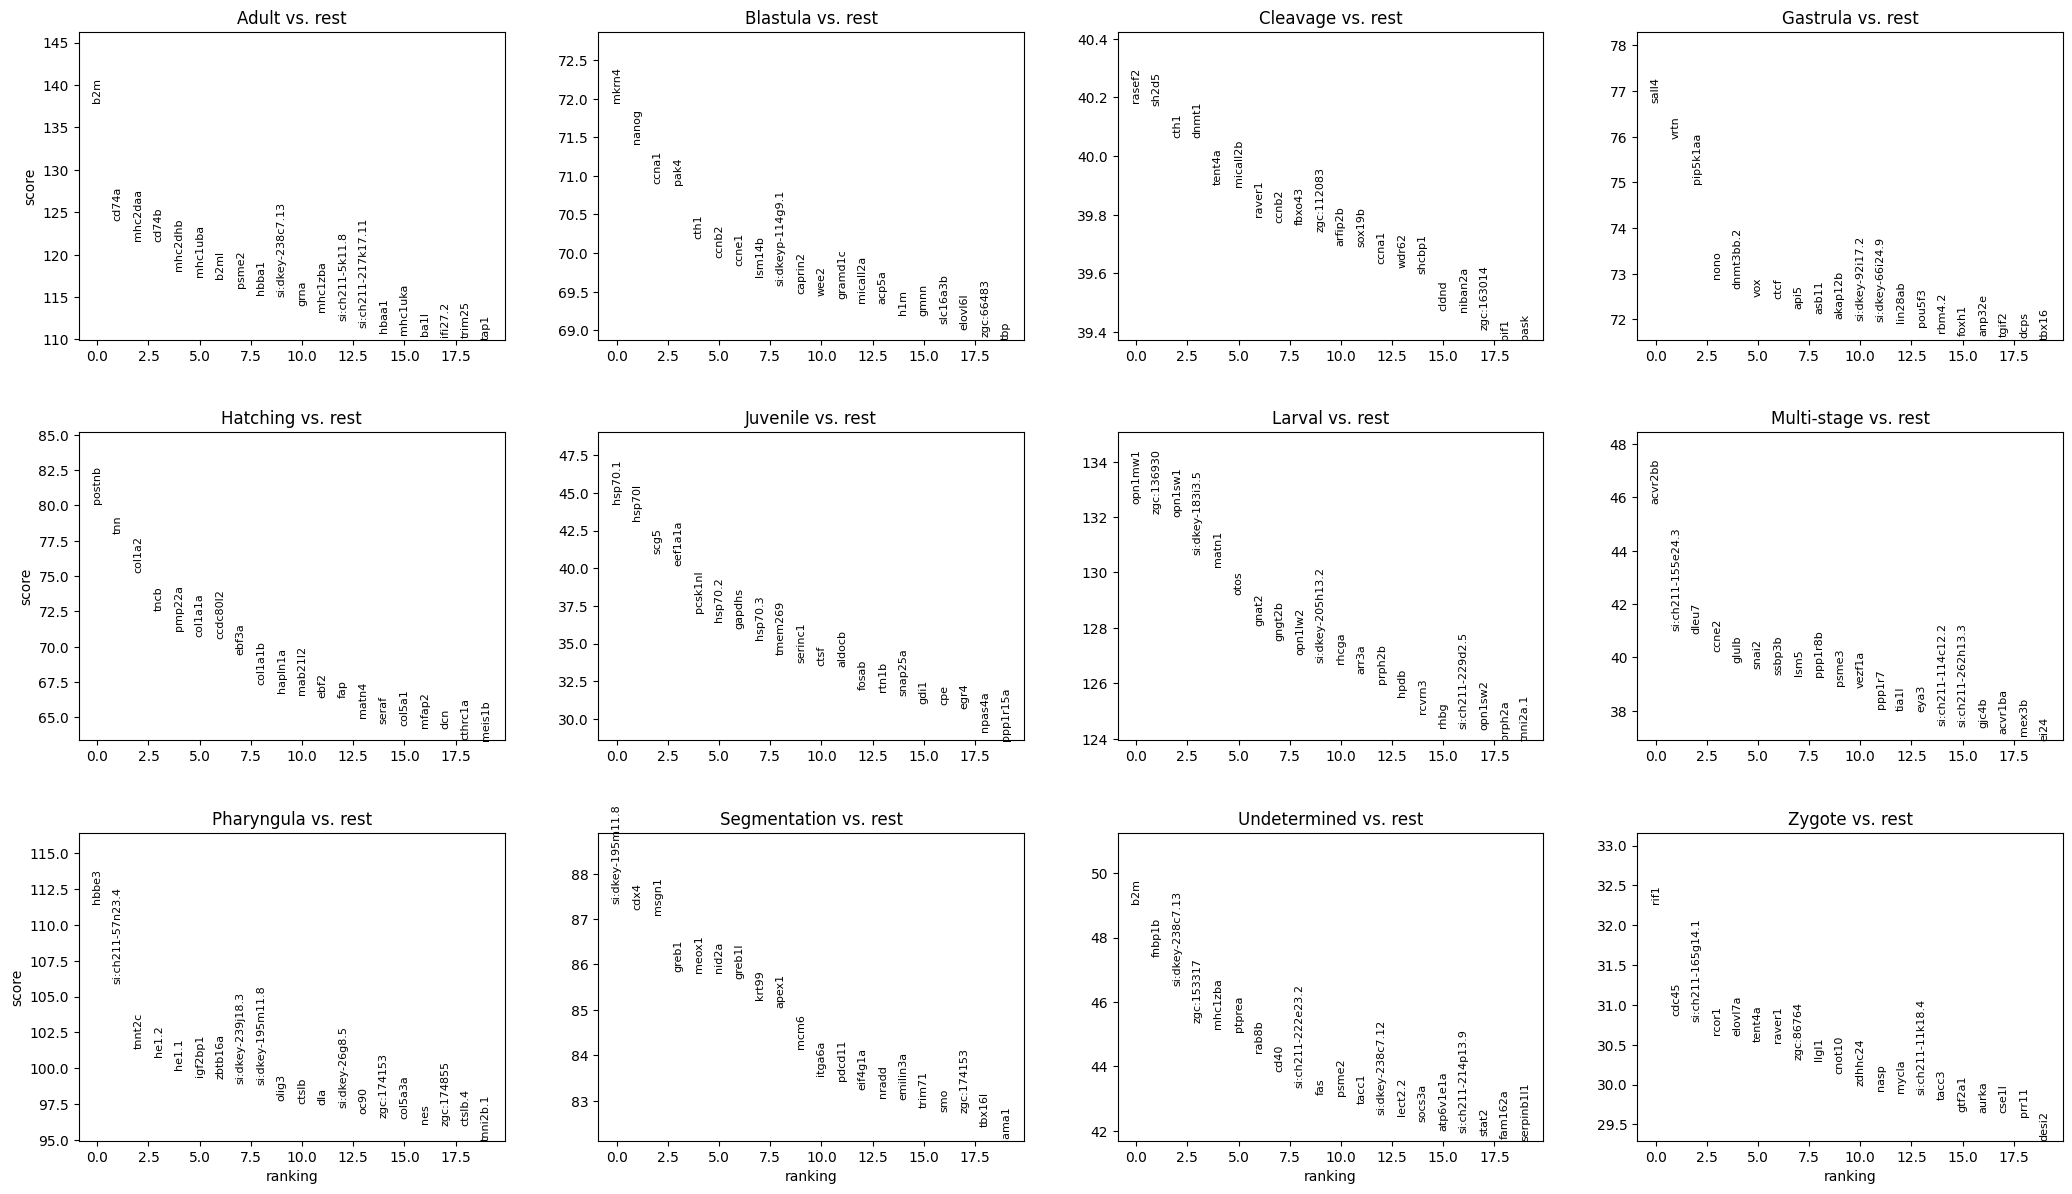

In [35]:
# Plot devstage marker genes and save to PDF
mpl.rcParams["pdf.fonttype"] = 42
sc.pl.rank_genes_groups(new_adata, key="rank_genes_groups", n_genes=20, sharey=False, show=False)
plt.savefig("output/devstage_curation_marker_genes.pdf", bbox_inches="tight")
plt.show()

In [36]:
obs_key = "tissue_curation_coarse"
markers_csv = f"output/{obs_key}_markers.csv"
markers_uns_pkl = f"output/{obs_key}_rank_genes_groups.pkl"

if FORCE_RECOMPUTE or not os.path.exists(markers_csv) or not os.path.exists(markers_uns_pkl):
    markers = compute_marker_genes(
        new_adata,
        obs_key=obs_key,
        reference="rest",
        method="wilcoxon",
        n_genes=50,
        rankby_abs=False,
    )
    markers.to_csv(markers_csv, index=False)
    with open(markers_uns_pkl, "wb") as f:
        pickle.dump(new_adata.uns["rank_genes_groups"], f)
    print(f"Computed and saved {obs_key} markers to {markers_csv}")
else:
    markers = pd.read_csv(markers_csv)
    with open(markers_uns_pkl, "rb") as f:
        new_adata.uns["rank_genes_groups"] = pickle.load(f)
    print(f"Loaded cached {obs_key} markers ({markers.shape[0]} rows)")

# Top 20 per cluster
top20 = (
    markers.sort_values(["group", "pvals_adj", "logfoldchanges"], ascending=[True, True, False])
           .groupby("group", as_index=False)
           .head(20)
)

Loaded cached tissue_curation_coarse markers (1050 rows)


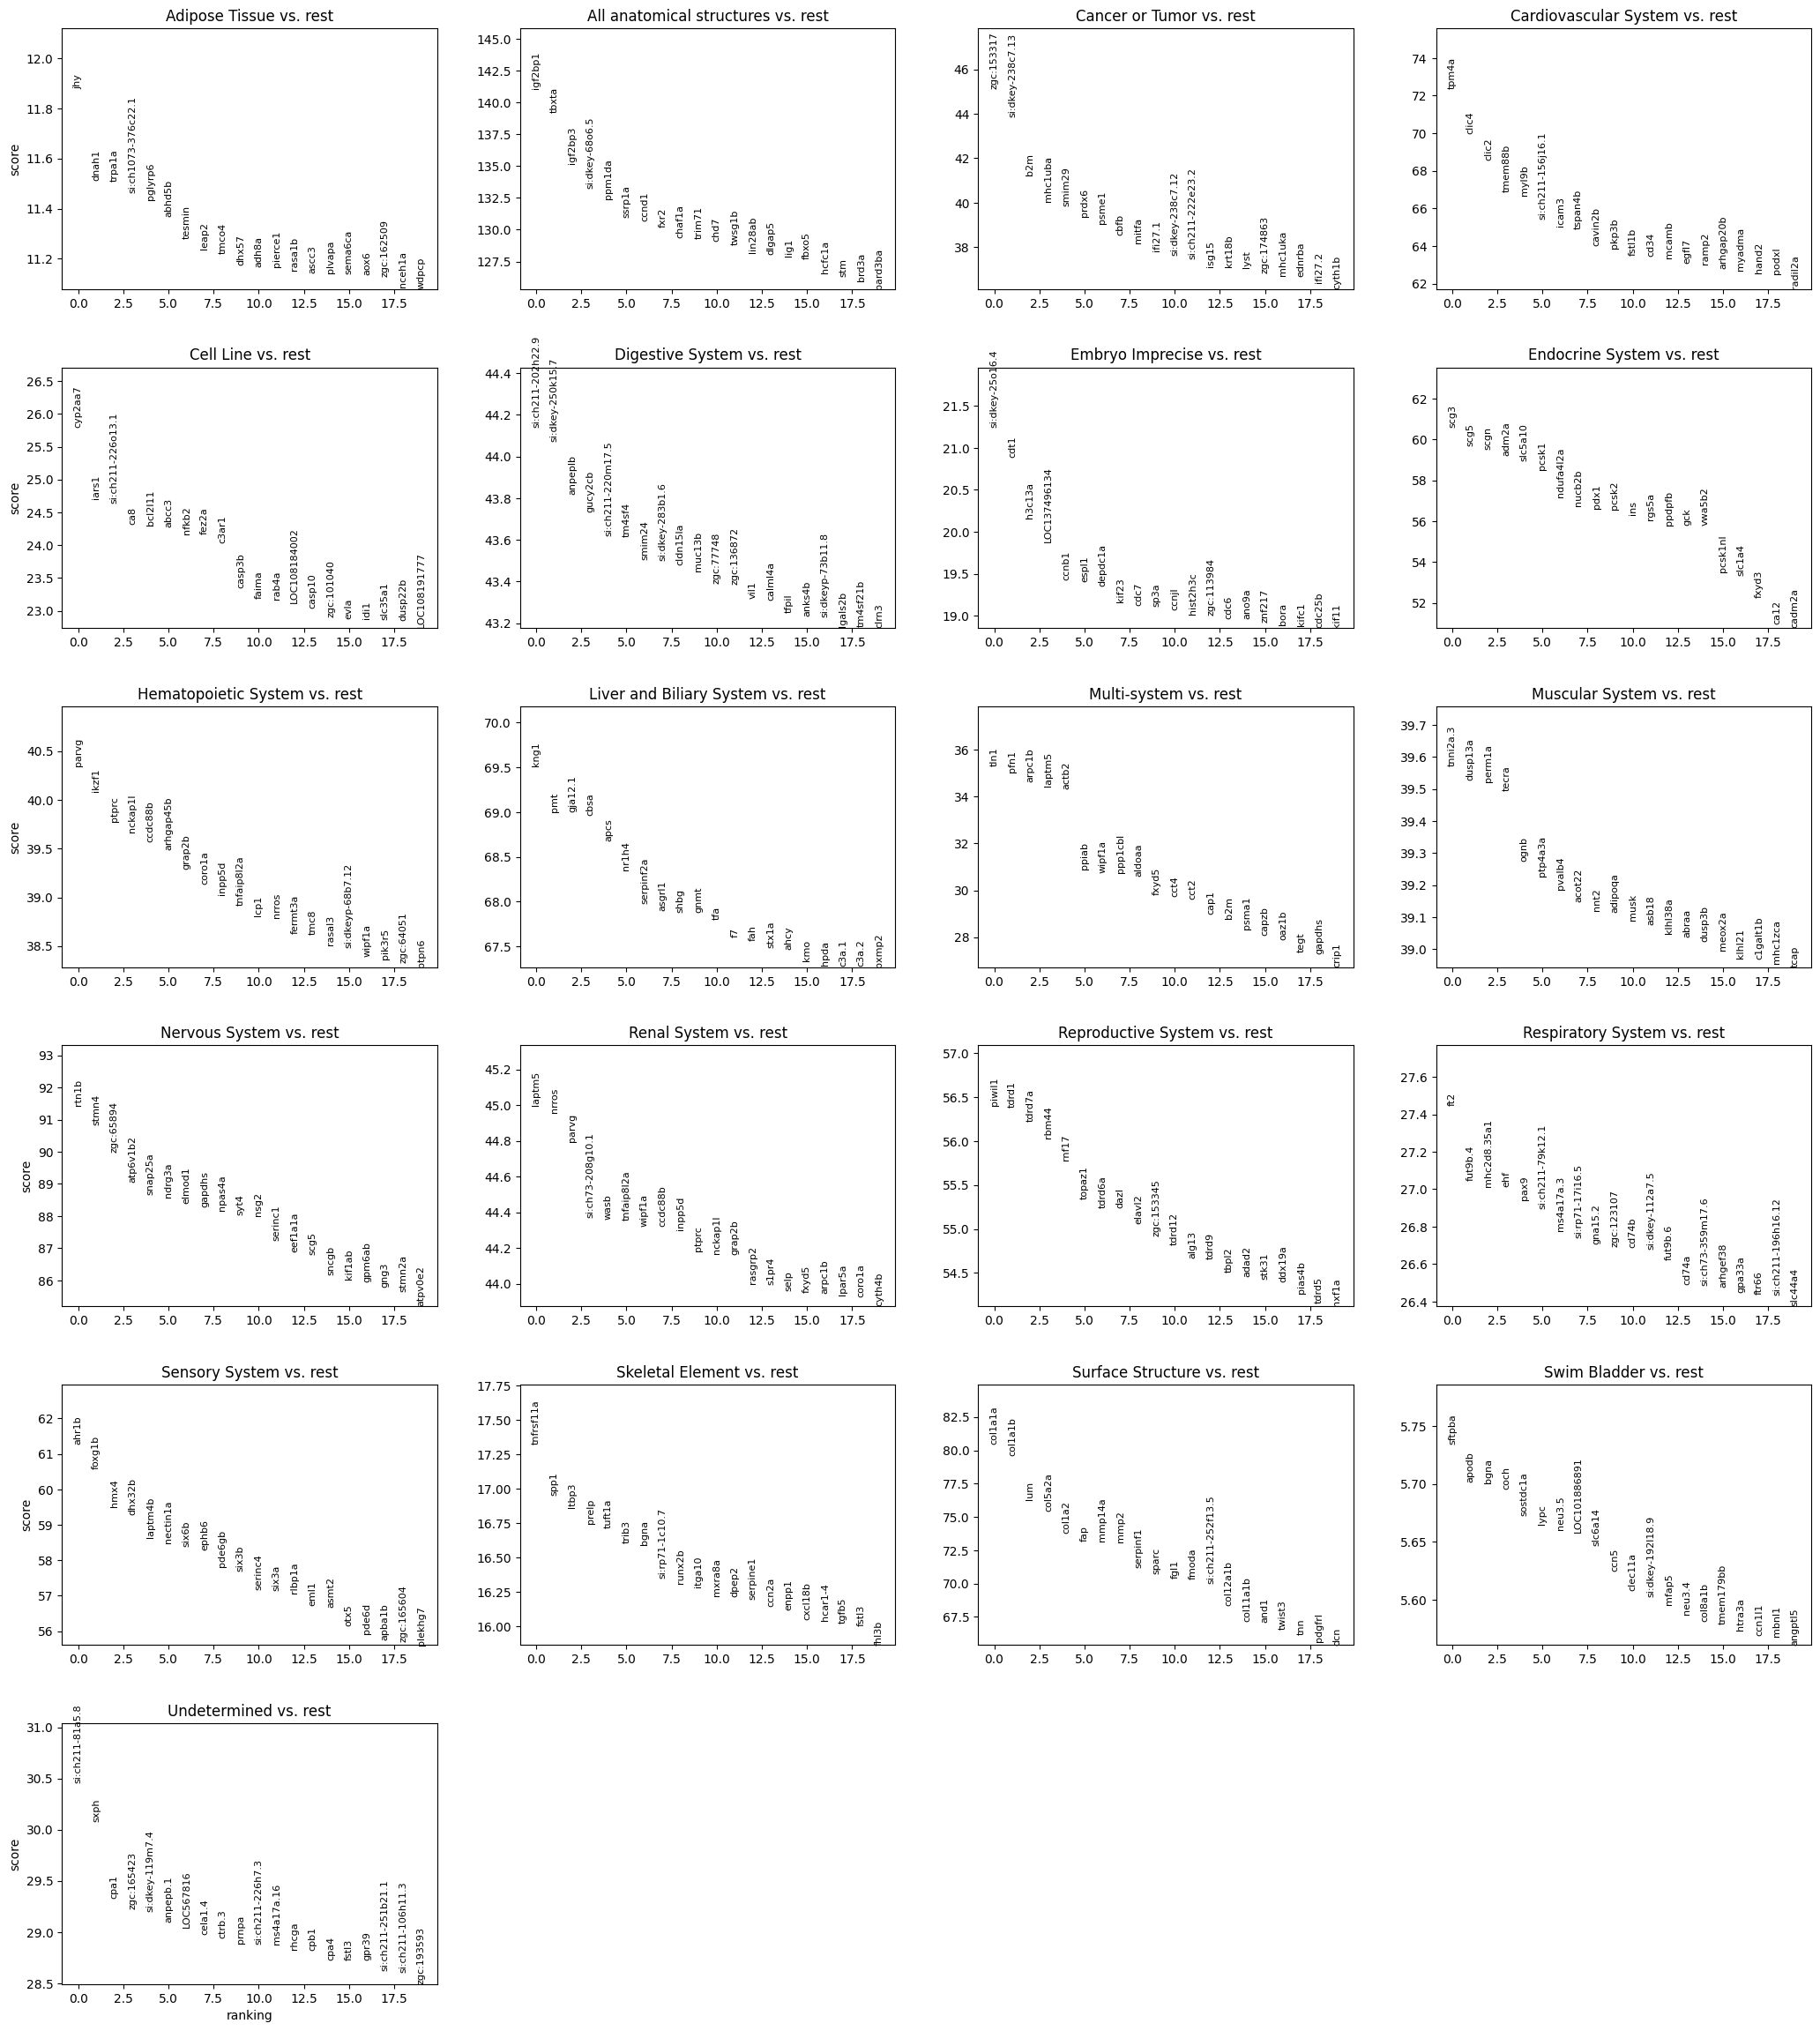

In [37]:
# Plot tissue marker genes and save to PDF
mpl.rcParams["pdf.fonttype"] = 42
sc.pl.rank_genes_groups(new_adata, key="rank_genes_groups", n_genes=20, sharey=False, show=False)
plt.savefig("output/tissue_curation_coarse_marker_genes.pdf", bbox_inches="tight")
plt.show()

### Validate computed markers against literature-curated zebrafish marker genes

Cross-reference the statistically computed marker genes (from Wilcoxon rank-sum tests) with
well-characterized zebrafish tissue- and stage-specific markers from published research.
Literature references are curated in `scripts/zebrafish_tissue_markers.py` and
`scripts/zebrafish_stage_markers.py`.

In [38]:
import sys
sys.path.insert(0, "Fig2/scripts")
from zebrafish_tissue_markers import ZEBRAFISH_TISSUE_MARKERS
from zebrafish_stage_markers import ZEBRAFISH_STAGE_MARKERS

# Build flat lookup: gene -> list of (source_type, group, role, refs)
def build_literature_lookup(tissue_dict, stage_dict):
    """Build a lookup from gene symbol to literature annotation(s)."""
    lookup = {}
    for tissue, entries in tissue_dict.items():
        for e in entries:
            gene = e["gene"]
            lookup.setdefault(gene, []).append({
                "source": "tissue",
                "group": tissue,
                "role": e.get("role", ""),
                "transgenic": e.get("transgenic", ""),
                "refs": e.get("refs", ""),
            })
    for stage, entries in stage_dict.items():
        for e in entries:
            gene = e["gene"]
            lookup.setdefault(gene, []).append({
                "source": "stage",
                "group": stage,
                "role": e.get("role", ""),
                "refs": e.get("ref", ""),
            })
    return lookup

lit_lookup = build_literature_lookup(ZEBRAFISH_TISSUE_MARKERS, ZEBRAFISH_STAGE_MARKERS)
print(f"Literature reference contains {len(lit_lookup)} unique marker genes")

Literature reference contains 217 unique marker genes


In [39]:
# Load both computed marker gene tables
tissue_markers = pd.read_csv("output/tissue_curation_coarse_markers.csv")
devstage_markers = pd.read_csv("output/devstage_curation_markers.csv")

print(f"Tissue markers: {tissue_markers.shape[0]} rows, {tissue_markers['group'].nunique()} groups")
print(f"DevStage markers: {devstage_markers.shape[0]} rows, {devstage_markers['group'].nunique()} groups")

Tissue markers: 1050 rows, 21 groups
DevStage markers: 600 rows, 12 groups


In [40]:
def cross_reference_markers(computed_df, lit_lookup, top_n=20):
    """
    Cross-reference computed markers with literature.
    Returns a DataFrame with literature annotations for each computed marker.
    """
    rows = []
    for group, grp_df in computed_df.groupby("group"):
        top = grp_df.sort_values("scores", ascending=False).head(top_n)
        for _, row in top.iterrows():
            gene = row["names"]
            in_lit = gene in lit_lookup
            lit_info = lit_lookup.get(gene, [])

            # Check if literature group matches computed group
            lit_groups = [e["group"] for e in lit_info]
            matched_group = group in lit_groups

            rows.append({
                "computed_group": group,
                "gene": gene,
                "score": row["scores"],
                "logFC": row["logfoldchanges"],
                "pval_adj": row["pvals_adj"],
                "in_literature": in_lit,
                "literature_match": matched_group,
                "lit_groups": "; ".join(lit_groups) if lit_groups else "",
                "lit_roles": "; ".join([e["role"] for e in lit_info]) if lit_info else "",
                "lit_refs": "; ".join([e.get("refs", e.get("ref", "")) for e in lit_info]) if lit_info else "",
            })
    return pd.DataFrame(rows)

#### Tissue marker validation

In [41]:
# Cross-reference tissue markers (top 20 per tissue)
tissue_xref = cross_reference_markers(tissue_markers, lit_lookup, top_n=20)

# Show literature-validated hits
tissue_validated = tissue_xref[tissue_xref["in_literature"]]
print(f"Tissue markers: {len(tissue_validated)} / {len(tissue_xref)} top-20 markers found in literature\n")

# Summary per tissue
tissue_summary = tissue_xref.groupby("computed_group").agg(
    total=("gene", "count"),
    in_lit=("in_literature", "sum"),
    matched_group=("literature_match", "sum"),
).assign(
    pct_in_lit=lambda x: (x["in_lit"] / x["total"] * 100).round(1),
    pct_matched=lambda x: (x["matched_group"] / x["total"] * 100).round(1),
)
tissue_summary

Tissue markers: 15 / 420 top-20 markers found in literature



,total,in_lit,matched_group,pct_in_lit,pct_matched
computed_group,,,,,
Adipose Tissue,20,0,0,0.0,0.0
All anatomical structures,20,2,0,10.0,0.0
Cancer or Tumor,20,1,0,5.0,0.0
Cardiovascular System,20,1,0,5.0,0.0
Cell Line,20,0,0,0.0,0.0
Digestive System,20,2,2,10.0,10.0
Embryo Imprecise,20,1,0,5.0,0.0
Endocrine System,20,2,2,10.0,10.0
Hematopoietic System,20,0,0,0.0,0.0


In [42]:
# Show validated tissue markers with their literature annotations
cols_show = ["computed_group", "gene", "score", "logFC", "literature_match", "lit_groups", "lit_roles", "lit_refs"]
tissue_validated_display = tissue_validated[cols_show].sort_values(["computed_group", "score"], ascending=[True, False])

# Print the matched ones (computed group == literature group)
tissue_matched = tissue_validated_display[tissue_validated_display["literature_match"]]
print(f"=== Tissue markers matching literature group ({len(tissue_matched)} hits) ===\n")
with pd.option_context("display.max_colwidth", 80, "display.max_rows", None):
    display(tissue_matched)

=== Tissue markers matching literature group (6 hits) ===



,computed_group,gene,score,logFC,literature_match,lit_groups,lit_roles,lit_refs
108,Digestive System,cldn15la,43.478214,10.591220,True,Digestive System,Intestinal epithelial cell marker (bulb to posterior intestine),PMID:21953180
112,Digestive System,vil1,43.318850,11.162268,True,Digestive System,Intestinal brush border marker; small intestine-enriched,PMID:19884307
148,Endocrine System,pdx1,56.618248,11.147115,True,Endocrine System,Pancreatic progenitor and beta-cell transcription factor,PMID:21989909
150,Endocrine System,ins,56.325100,18.966700,True,Digestive System; Endocrine System; Hatching,Pancreatic beta-cell marker; Pancreatic beta-cell marker; most used endocrin...,PMID:21953180; PMID:21953180; PMID: 30678246
280,Reproductive System,piwil1,56.403893,9.345334,True,Reproductive System,Germ cell marker; expressed in PGCs and gamete progenitors,PMID:30814499
348,Skeletal Element,runx2b,16.312525,5.570169,True,Skeletal Element; Juvenile,Osteoblast differentiation; duplicate of runx2a with subfunctionalization; O...,"PMID:36103880; PMID: 22373977 (DeLaurier et al., BMC Evol Biol 2012)"


In [43]:
# Show literature-annotated genes whose computed group doesn't match literature expectation
tissue_mismatched = tissue_validated_display[~tissue_validated_display["literature_match"]]
if len(tissue_mismatched) > 0:
    print(f"=== Tissue markers in literature but assigned to a different group ({len(tissue_mismatched)} hits) ===")
    print("(These genes are known markers for a different tissue than where they rank highest)\n")
    with pd.option_context("display.max_colwidth", 80, "display.max_rows", None):
        display(tissue_mismatched)
else:
    print("No mismatches found.")

=== Tissue markers in literature but assigned to a different group (9 hits) ===
(These genes are known markers for a different tissue than where they rank highest)



,computed_group,gene,score,logFC,literature_match,lit_groups,lit_roles,lit_refs
21,All anatomical structures,tbxta,139.193860,4.393261,False,Gastrula,"T-box TF (Brachyury/ntla); pan-mesodermal, marks notochord precursors","PMID: 7600961 (Schulte-Merker et al., Development 1994)"
26,All anatomical structures,ccnd1,130.663760,3.983374,False,Blastula,Cyclin D1; rises at MBT as cell cycles lengthen (replaces ccnb1),PMID: 16284195
42,Cancer or Tumor,b2m,41.243996,9.157654,False,Multi-stage,"Beta-2-microglobulin; immune-related housekeeping, stable in geNorm analysis",PMID: 19014500
77,Cardiovascular System,hand2,62.551450,6.186636,False,Liver and Biliary System; Pharyngula,Hepatic stellate cell marker; bHLH TF; anterior lateral plate mesoderm / car...,"PMID:21953180; PMID: 25030173 (Schindler et al., Development 2014)"
124,Embryo Imprecise,ccnb1,19.425964,4.779752,False,Zygote; Cleavage,"Cyclin B1; maternally loaded, drives rapid S/M cell cycles pre-MBT; Cyclin B...","PMID: 16284195 (Duffy et al., Nucleic Acids Res 2005); PMID: 16284195"
204,Multi-system,actb2,34.332207,1.577253,False,Multi-stage,Beta-actin 2; broadly expressed cytoskeletal gene,PMID: 21281742
213,Multi-system,b2m,28.795279,3.328390,False,Multi-stage,"Beta-2-microglobulin; immune-related housekeeping, stable in geNorm analysis",PMID: 19014500
287,Reproductive System,dazl,55.240730,9.405025,False,Zygote,Maternal germplasm mRNA; RNA-binding protein in germ cell specification,"PMID: 11701882 (Hashimoto et al., Dev Growth Differ 2004)"
360,Surface Structure,col1a1a,80.439130,6.337545,False,Skeletal Element,Osteoblast matrix protein; major bone collagen,PMID:19288476


#### Developmental stage marker validation

In [44]:
# Cross-reference developmental stage markers (top 20 per stage)
stage_xref = cross_reference_markers(devstage_markers, lit_lookup, top_n=20)

stage_validated = stage_xref[stage_xref["in_literature"]]
print(f"DevStage markers: {len(stage_validated)} / {len(stage_xref)} top-20 markers found in literature\n")

# Summary per stage
stage_summary = stage_xref.groupby("computed_group").agg(
    total=("gene", "count"),
    in_lit=("in_literature", "sum"),
    matched_group=("literature_match", "sum"),
).assign(
    pct_in_lit=lambda x: (x["in_lit"] / x["total"] * 100).round(1),
    pct_matched=lambda x: (x["matched_group"] / x["total"] * 100).round(1),
)
stage_summary

DevStage markers: 15 / 240 top-20 markers found in literature



,total,in_lit,matched_group,pct_in_lit,pct_matched
computed_group,,,,,
Adult,20,1,0,5.0,0.0
Blastula,20,3,1,15.0,5.0
Cleavage,20,2,0,10.0,0.0
Gastrula,20,1,0,5.0,0.0
Hatching,20,1,0,5.0,0.0
Juvenile,20,0,0,0.0,0.0
Larval,20,3,0,15.0,0.0
Multi-stage,20,0,0,0.0,0.0
Pharyngula,20,1,1,5.0,5.0


In [45]:
# Show validated stage markers with literature annotations
cols_show = ["computed_group", "gene", "score", "logFC", "literature_match", "lit_groups", "lit_roles", "lit_refs"]
stage_validated_display = stage_validated[cols_show].sort_values(["computed_group", "score"], ascending=[True, False])

stage_matched = stage_validated_display[stage_validated_display["literature_match"]]
print(f"=== Stage markers matching literature group ({len(stage_matched)} hits) ===\n")
with pd.option_context("display.max_colwidth", 80, "display.max_rows", None):
    display(stage_matched)

=== Stage markers matching literature group (3 hits) ===



,computed_group,gene,score,logFC,literature_match,lit_groups,lit_roles,lit_refs
21,Blastula,nanog,71.41310,12.579640,True,Zygote; Cleavage; Blastula,Maternal pluripotency TF; activates zygotic genes at MZT; Maternal pluripote...,"PMID: 24141950 (Lee et al., Nature 2013); PMID: 24141950; PMID: 24141950"
164,Pharyngula,he1.1,99.87376,8.768125,True,Pharyngula; Hatching,Hatching enzyme 1; metalloprotease in hatching gland cells; Hatching enzyme ...,"PMID: 31558744 (Wang et al., Sci Rep 2019); PMID: 31558744"
182,Segmentation,msgn1,87.09683,9.824492,True,Segmentation,Mesogenin 1; marks PSM progenitor domain in tailbud,PMID: 25725067


In [46]:
# Stage markers annotated in literature but assigned to a different group
stage_mismatched = stage_validated_display[~stage_validated_display["literature_match"]]
if len(stage_mismatched) > 0:
    print(f"=== Stage markers in literature but assigned to a different group ({len(stage_mismatched)} hits) ===\n")
    with pd.option_context("display.max_colwidth", 80, "display.max_rows", None):
        display(stage_mismatched)
else:
    print("No mismatches found.")

=== Stage markers in literature but assigned to a different group (12 hits) ===



,computed_group,gene,score,logFC,literature_match,lit_groups,lit_roles,lit_refs
0,Adult,b2m,137.869750,9.424764,False,Multi-stage,"Beta-2-microglobulin; immune-related housekeeping, stable in geNorm analysis",PMID: 19014500
25,Blastula,ccnb2,69.947650,9.006345,False,Zygote,"Cyclin B2; maternally loaded cell cycle regulator, declines post-MBT",PMID: 16284195
39,Blastula,tbp,68.876080,5.347689,False,Multi-stage,"TATA-binding protein; basal transcription factor, reference gene",PMID: 19014500
47,Cleavage,ccnb2,39.774563,10.430883,False,Zygote,"Cyclin B2; maternally loaded cell cycle regulator, declines post-MBT",PMID: 16284195
51,Cleavage,sox19b,39.690594,8.178885,False,Zygote; Blastula,Maternal SoxB1 TF; co-activates ZGA targets with Nanog/Pou5f3; SoxB1 family ...,"PMID: 24141950; PMID: 31988314 (Pálfy et al., 2020); PMID: 24141950"
73,Gastrula,pou5f3,71.852910,10.803077,False,Zygote; Cleavage; Blastula,Maternal pluripotency TF (Oct4 ortholog); primes ZGA; Maternal Oct4-like TF;...,"PMID: 24141950 (Lee et al., Nature 2013); PMID: 24141950; PMID: 31988314 (Pá..."
85,Hatching,col1a1a,70.687330,5.699524,False,Skeletal Element,Osteoblast matrix protein; major bone collagen,PMID:19288476
120,Larval,opn1mw1,132.494500,8.647367,False,Sensory System,Green-sensitive cone photoreceptor marker,PMID:26260523
122,Larval,opn1sw1,132.008870,9.868454,False,Sensory System,UV-sensitive cone photoreceptor marker,PMID:26260523
137,Larval,opn1sw2,124.337120,6.664229,False,Sensory System,Blue-sensitive cone photoreceptor marker,PMID:26260523


#### Tissue marker panels with literature-curated genes highlighted

Show `sc.pl.rank_genes_groups`-style bar plots for select tissues. Gene labels in
**red** are found in the curated literature reference for that tissue.

In [50]:
# Build per-tissue literature gene sets AND a flat set of all literature genes
lit_genes_by_tissue = {}
for tissue, entries in ZEBRAFISH_TISSUE_MARKERS.items():
    lit_genes_by_tissue[tissue] = {e["gene"] for e in entries}
all_lit_genes = set().union(*lit_genes_by_tissue.values())

# Select tissues that have literature genes in their top 20 computed markers
HIGHLIGHT_TISSUES = ["Reproductive System", "Skeletal Element", "Digestive System", "Endocrine System"]

# Reload tissue rank_genes_groups into new_adata.uns
tissue_uns_pkl = "output/tissue_curation_coarse_rank_genes_groups.pkl"
with open(tissue_uns_pkl, "rb") as f:
    new_adata.uns["rank_genes_groups"] = pickle.load(f)

In [51]:
# Download ZFIN bulk expression file and build set of genes WITH expression data
import urllib.request

ZFIN_XPAT_URL = "https://zfin.org/downloads/xpat_fish.txt"
ZFIN_XPAT_CACHE = os.path.join(CACHE_DIR, "zfin_xpat_fish.txt")

if FORCE_RECOMPUTE or not os.path.exists(ZFIN_XPAT_CACHE):
    print(f"Downloading ZFIN expression data from {ZFIN_XPAT_URL} ...")
    urllib.request.urlretrieve(ZFIN_XPAT_URL, ZFIN_XPAT_CACHE)
    print(f"Saved to {ZFIN_XPAT_CACHE}")
else:
    print(f"Using cached ZFIN expression file: {ZFIN_XPAT_CACHE}")

# Parse: collect gene symbols that have expression data
# xpat_fish.txt columns: Gene_ZDB_ID, Gene_Symbol, Probe_ZDB_ID, Probe_Name, ...
zfin_genes_with_expr = set()
with open(ZFIN_XPAT_CACHE) as f:
    for line in f:
        if line.startswith("ZDB-GENE-"):
            cols = line.strip().split("\t")
            if len(cols) >= 2:
                zfin_genes_with_expr.add(cols[1])  # gene symbol

print(f"ZFIN: {len(zfin_genes_with_expr)} genes have expression data")

Using cached ZFIN expression file: output/zfin_xpat_fish.txt
ZFIN: 14923 genes have expression data


In [52]:
# Validate automated ZFIN expression lookup against manual annotations
manual_path = "data/marker_gene_expression_manual_data.csv"
if os.path.exists(manual_path):
    manual = {}
    with open(manual_path) as f:
        for line in f:
            cols = line.strip().split(",")
            if len(cols) >= 3:
                tissue, gene, status = cols[0], cols[1], cols[2]
                manual.setdefault(tissue, {})[gene] = status

    print("=== Validation: automated ZFIN lookup vs manual annotations ===\n")
    for tissue in sorted(manual.keys()):
        genes = manual[tissue]
        tp = tn = fp = fn = 0
        mismatches = []
        for gene, status in genes.items():
            manual_has = status in ("Y", "YY")
            auto_has = gene in zfin_genes_with_expr
            if manual_has and auto_has: tp += 1
            elif not manual_has and not auto_has: tn += 1
            elif not manual_has and auto_has:
                fp += 1
                mismatches.append((gene, "N", "Y"))
            else:
                fn += 1
                mismatches.append((gene, "Y/YY", "N"))

        total = tp + tn + fp + fn
        acc = (tp + tn) / total * 100 if total else 0
        print(f"{tissue}: {total} genes, TP={tp} TN={tn} FP={fp} FN={fn}, accuracy={acc:.1f}%")
        for gene, m, a in mismatches:
            print(f"  MISMATCH: {gene:25s} manual={m} auto={a}")
    print()
else:
    print(f"Manual validation file not found at {manual_path} — skipping")

=== Validation: automated ZFIN lookup vs manual annotations ===

Digestive System: 50 genes, TP=26 TN=24 FP=0 FN=0, accuracy=100.0%



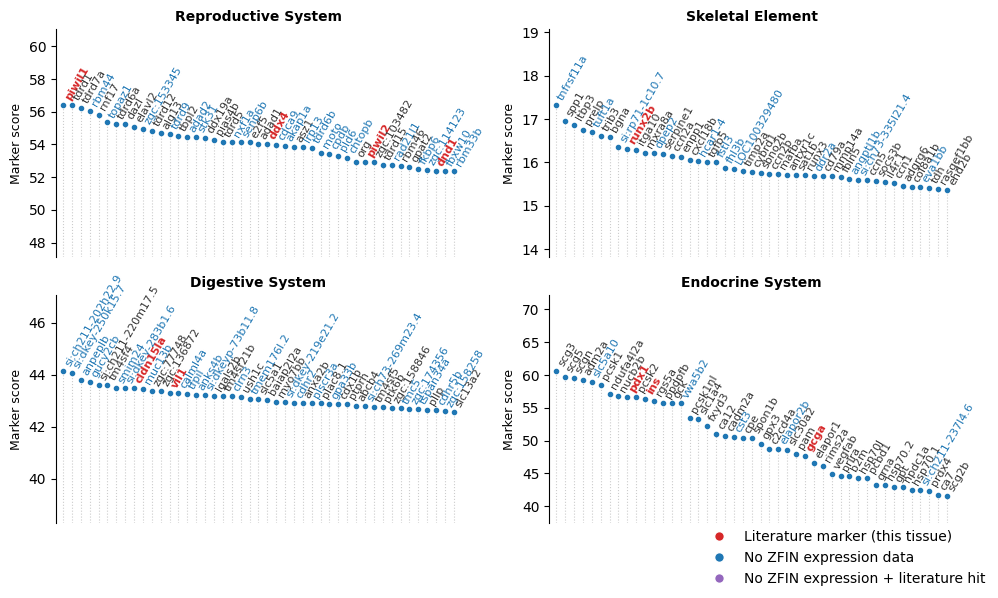

Saved to output/tissue_marker_panels_highlighted.pdf/.png


In [53]:
N_GENES_SHOW = 45
HIGHLIGHT_COLOR = "#d62728"       # red — literature marker for THIS tissue
NO_EXPR_COLOR = "#1f77b4"         # blue — no ZFIN expression data
NO_EXPR_LIT_COLOR = "#9467bd"     # purple — no ZFIN expression data + literature hit
DEFAULT_COLOR = "#333333"

# Adjustable font sizes
GENE_FONTSIZE = 8
TITLE_FONTSIZE = 10
AXIS_LABEL_FONTSIZE = 9
TICK_FONTSIZE = 10
LEGEND_FONTSIZE = 10

mpl.rcParams["pdf.fonttype"] = 42

# Extract gene names and scores from the rank_genes_groups result
rgg = new_adata.uns["rank_genes_groups"]
group_names = rgg["names"].dtype.names

panels = []
for tissue in HIGHLIGHT_TISSUES:
    if tissue in group_names:
        n = min(N_GENES_SHOW, len(rgg["names"][tissue]))
        genes = [rgg["names"][tissue][i] for i in range(n)]
        scores = [rgg["scores"][tissue][i] for i in range(n)]
        panels.append((tissue, genes, scores))

def gene_color_weight(gene, same_tissue_set):
    """Assign color and weight based on literature + ZFIN expression status."""
    in_same_tissue = gene in same_tissue_set
    has_zfin_expr = gene in zfin_genes_with_expr

    if in_same_tissue and not has_zfin_expr:
        return NO_EXPR_LIT_COLOR, "bold"     # purple: lit match + no ZFIN expr
    elif in_same_tissue:
        return HIGHLIGHT_COLOR, "bold"        # red: lit match for this tissue
    elif not has_zfin_expr:
        return NO_EXPR_COLOR, "normal"        # blue: no ZFIN expression data
    else:
        return DEFAULT_COLOR, "normal"        # black: default

nrows, ncols = 2, 2
fig, axes = plt.subplots(nrows, ncols, figsize=(10, 6), squeeze=False)
axes_flat = axes.ravel()

for idx, (ax, (tissue, genes, scores)) in enumerate(zip(axes_flat, panels)):
    same_tissue_set = lit_genes_by_tissue.get(tissue, set())
    x = np.arange(len(genes))
    y_min = min(scores) * 0.9
    score_range = max(scores) - y_min
    pad = score_range * 0.02

    for i, (gene, score) in enumerate(zip(genes, scores)):
        color, weight = gene_color_weight(gene, same_tissue_set)
        ax.text(
            i, score + pad, gene,
            rotation=60, ha="left", va="bottom",
            fontsize=GENE_FONTSIZE, color=color, fontweight=weight,
        )

    ax.vlines(x, y_min, scores, color="#cccccc", linewidth=0.8, linestyle=":")
    ax.plot(x, scores, "o", color="#1f77b4", markersize=3)

    ax.set_title(tissue, fontsize=TITLE_FONTSIZE, fontweight="bold")
    ax.set_ylabel("Marker score", fontsize=AXIS_LABEL_FONTSIZE)
    ax.set_xticks([])
    ax.tick_params(axis="y", labelsize=TICK_FONTSIZE)
    ax.set_xlim(-0.8, len(genes) - 0.2)
    ax.set_ylim(y_min, max(scores) + score_range * 0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_visible(False)

# Hide unused axes
for idx in range(len(panels), nrows * ncols):
    axes_flat[idx].set_visible(False)

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=HIGHLIGHT_COLOR, label="Literature marker (this tissue)", markersize=7),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=NO_EXPR_COLOR, label="No ZFIN expression data", markersize=7),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=NO_EXPR_LIT_COLOR, label="No ZFIN expression + literature hit", markersize=7),
]
fig.legend(handles=legend_elements, loc="lower right", fontsize=LEGEND_FONTSIZE, frameon=False)

plt.tight_layout()
fig.subplots_adjust(bottom=0.12)
fig.savefig("output/tissue_marker_panels_highlighted.pdf", bbox_inches="tight")
fig.savefig("output/tissue_marker_panels_highlighted.png", bbox_inches="tight", dpi=300)
plt.show()
print("Saved to output/tissue_marker_panels_highlighted.pdf/.png")

In [54]:
# Build a reference table for all highlighted genes in the panels above
ref_rows = []
for tissue, genes, scores in panels:
    same_tissue_set = lit_genes_by_tissue.get(tissue, set())
    for gene, score in zip(genes, scores):
        # Check same-tissue literature
        if gene in same_tissue_set:
            for entry in ZEBRAFISH_TISSUE_MARKERS.get(tissue, []):
                if entry["gene"] == gene:
                    ref_rows.append({
                        "panel": tissue,
                        "gene": gene,
                        "score": round(score, 1),
                        "match": "same tissue",
                        "lit_tissue": tissue,
                        "role": entry.get("role", ""),
                        "transgenic": entry.get("transgenic", ""),
                        "refs": entry.get("refs", ""),
                    })
        # Check other-tissue literature
        elif gene in all_lit_genes:
            for lit_tissue, entries in ZEBRAFISH_TISSUE_MARKERS.items():
                for entry in entries:
                    if entry["gene"] == gene:
                        ref_rows.append({
                            "panel": tissue,
                            "gene": gene,
                            "score": round(score, 1),
                            "match": "other tissue",
                            "lit_tissue": lit_tissue,
                            "role": entry.get("role", ""),
                            "transgenic": entry.get("transgenic", ""),
                            "refs": entry.get("refs", ""),
                        })

if ref_rows:
    ref_df = pd.DataFrame(ref_rows)
    print(f"Literature references for {len(ref_df)} highlighted marker genes:\n")
    with pd.option_context("display.max_colwidth", 80, "display.max_rows", None, "display.width", 200):
        display(ref_df)
    ref_df.to_csv("output/highlighted_markers_literature_refs.csv", index=False)
    print(f"\nSaved to output/highlighted_markers_literature_refs.csv")
else:
    print("No highlighted genes found in literature.")

Literature references for 10 highlighted marker genes:



,panel,gene,score,match,lit_tissue,role,transgenic,refs
0,Reproductive System,piwil1,56.400002,same tissue,Reproductive System,Germ cell marker; expressed in PGCs and gamete progenitors,"Tg(piwil1:EGFP), Tg(piwil1:EGFP-UTRnanos3)",PMID:30814499
1,Reproductive System,ddx4,54.000000,same tissue,Reproductive System,Conserved germ cell marker; labels primordial germ cells (PGCs) and all germ...,Tg(ddx4:ddx4-EGFP) / Tg(vasa:vasa-EGFP),PMID:11463859
2,Reproductive System,piwil2,52.900002,same tissue,Reproductive System,Germ cell marker; required for meiosis and transposon silencing,Mutant lines,PMID:20360737
3,Reproductive System,dnd1,52.400002,same tissue,Reproductive System,Essential for PGC survival; loss causes all-male fish (no germ cells),dnd1 morpholino; mutant lines,PMID:14973291
4,Skeletal Element,runx2b,16.299999,same tissue,Skeletal Element,Osteoblast differentiation; duplicate of runx2a with subfunctionalization,ISH / mutant studies,PMID:36103880
5,Digestive System,cldn15la,43.500000,same tissue,Digestive System,Intestinal epithelial cell marker (bulb to posterior intestine),TgBAC(cldn15la:GFP),PMID:21953180
6,Digestive System,vil1,43.299999,same tissue,Digestive System,Intestinal brush border marker; small intestine-enriched,ISH probe,PMID:19884307
7,Endocrine System,pdx1,56.599998,same tissue,Endocrine System,Pancreatic progenitor and beta-cell transcription factor,Tg(pdx1:GFP),PMID:21989909
8,Endocrine System,ins,56.299999,same tissue,Endocrine System,Pancreatic beta-cell marker; most used endocrine pancreas promoter,"Tg(ins:DsRed), Tg(ins:GFP), Tg(ins:NTR-mCherry)",PMID:21953180
9,Endocrine System,gcga,47.700001,same tissue,Endocrine System,Pancreatic alpha-cell marker,"Tg(gcga:GFP), Tg(gcga:Cre)",PMID:37516089



Saved to output/highlighted_markers_literature_refs.csv


#### Developmental stage marker panels with literature-curated genes highlighted

In [55]:
# Build per-stage literature gene sets
lit_genes_by_stage = {}
for stage, entries in ZEBRAFISH_STAGE_MARKERS.items():
    lit_genes_by_stage[stage] = {e["gene"] for e in entries}
all_lit_stage_genes = set().union(*lit_genes_by_stage.values())

HIGHLIGHT_STAGES = ["Segmentation", "Pharyngula", "Larval", "Adult"]

# Load devstage rank_genes_groups into new_adata.uns
devstage_uns_pkl = "output/devstage_curation_rank_genes_groups.pkl"
with open(devstage_uns_pkl, "rb") as f:
    new_adata.uns["rank_genes_groups"] = pickle.load(f)

print(f"Stage literature: {len(all_lit_stage_genes)} unique genes")
for s in HIGHLIGHT_STAGES:
    print(f"  {s}: {sorted(lit_genes_by_stage.get(s, set()))}")

Stage literature: 92 unique genes
  Segmentation: ['dlc', 'egr2b', 'gata1a', 'her1', 'her7', 'lmo2', 'mespba', 'msgn1', 'myf5', 'myod1', 'neurog1', 'pax2a', 'tal1', 'tbx6']
  Pharyngula: ['ctsl1b', 'dlx2a', 'elavl3', 'hand2', 'he1.1', 'hoxa2b', 'isl1', 'lyz', 'mpx', 'myl7', 'nkx2.5', 'otx2b', 'pax6a', 'rx3', 'shha', 'sox10']
  Larval: ['fabp10a', 'fabp2', 'igfbp1a', 'krt4', 'lyz', 'mpx', 'rag1', 'rag2', 'slc6a3', 'sp7', 'tp63']
  Adult: ['amh', 'cyp19a1a', 'cyp19a1b', 'fabp10a', 'gsdf', 'krt4', 'mbp', 'rag1', 'tp63', 'vtg1']


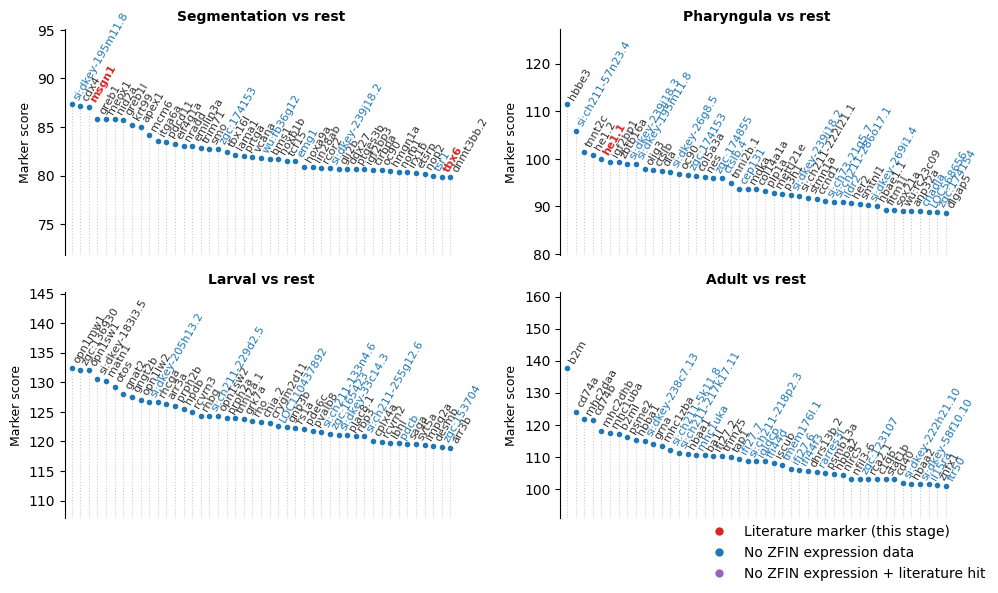

Saved to output/devstage_marker_panels_highlighted.pdf/.png


In [56]:
N_GENES_SHOW_STAGE = N_GENES_SHOW  # same as tissue panels

mpl.rcParams["pdf.fonttype"] = 42

rgg = new_adata.uns["rank_genes_groups"]
group_names = rgg["names"].dtype.names

stage_panels = []
for stage in HIGHLIGHT_STAGES:
    if stage in group_names:
        n = min(N_GENES_SHOW_STAGE, len(rgg["names"][stage]))
        genes = [rgg["names"][stage][i] for i in range(n)]
        scores = [rgg["scores"][stage][i] for i in range(n)]
        stage_panels.append((stage, genes, scores))

def stage_gene_color_weight(gene, same_stage_set):
    """Assign color and weight based on stage literature + ZFIN expression status."""
    in_same_stage = gene in same_stage_set
    has_zfin_expr = gene in zfin_genes_with_expr

    if in_same_stage and not has_zfin_expr:
        return NO_EXPR_LIT_COLOR, "bold"
    elif in_same_stage:
        return HIGHLIGHT_COLOR, "bold"
    elif not has_zfin_expr:
        return NO_EXPR_COLOR, "normal"
    else:
        return DEFAULT_COLOR, "normal"

nrows, ncols = 2, 2
fig, axes = plt.subplots(nrows, ncols, figsize=(10, 6), squeeze=False)
axes_flat = axes.ravel()

for idx, (ax, (stage, genes, scores)) in enumerate(zip(axes_flat, stage_panels)):
    same_stage_set = lit_genes_by_stage.get(stage, set())
    x = np.arange(len(genes))
    y_min = min(scores) * 0.9
    score_range = max(scores) - y_min
    pad = score_range * 0.02

    for i, (gene, score) in enumerate(zip(genes, scores)):
        color, weight = stage_gene_color_weight(gene, same_stage_set)
        ax.text(
            i, score + pad, gene,
            rotation=60, ha="left", va="bottom",
            fontsize=GENE_FONTSIZE, color=color, fontweight=weight,
        )

    ax.vlines(x, y_min, scores, color="#cccccc", linewidth=0.8, linestyle=":")
    ax.plot(x, scores, "o", color="#1f77b4", markersize=3)

    ax.set_title(f"{stage} vs rest", fontsize=TITLE_FONTSIZE, fontweight="bold")
    ax.set_ylabel("Marker score", fontsize=AXIS_LABEL_FONTSIZE)
    ax.set_xticks([])
    ax.tick_params(axis="y", labelsize=TICK_FONTSIZE)
    ax.set_xlim(-0.8, len(genes) - 0.2)
    ax.set_ylim(y_min, max(scores) + score_range * 0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_visible(False)

# Hide unused axes
for idx in range(len(stage_panels), nrows * ncols):
    axes_flat[idx].set_visible(False)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=HIGHLIGHT_COLOR, label="Literature marker (this stage)", markersize=7),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=NO_EXPR_COLOR, label="No ZFIN expression data", markersize=7),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=NO_EXPR_LIT_COLOR, label="No ZFIN expression + literature hit", markersize=7),
]
fig.legend(handles=legend_elements, loc="lower right", fontsize=LEGEND_FONTSIZE, frameon=False)

plt.tight_layout()
fig.subplots_adjust(bottom=0.12)
fig.savefig("output/devstage_marker_panels_highlighted.pdf", bbox_inches="tight")
fig.savefig("output/devstage_marker_panels_highlighted.png", bbox_inches="tight", dpi=300)
plt.show()
print("Saved to output/devstage_marker_panels_highlighted.pdf/.png")

In [57]:
# Reference table for highlighted devstage markers
stage_ref_rows = []
for stage, genes, scores in stage_panels:
    same_stage_set = lit_genes_by_stage.get(stage, set())
    for gene, score in zip(genes, scores):
        if gene in same_stage_set:
            for entry in ZEBRAFISH_STAGE_MARKERS.get(stage, []):
                if entry["gene"] == gene:
                    stage_ref_rows.append({
                        "panel": f"{stage} vs rest",
                        "gene": gene,
                        "score": round(score, 1),
                        "role": entry.get("role", ""),
                        "refs": entry.get("ref", ""),
                        "has_zfin_expr": gene in zfin_genes_with_expr,
                    })

if stage_ref_rows:
    stage_ref_df = pd.DataFrame(stage_ref_rows)
    print(f"Literature references for {len(stage_ref_df)} highlighted devstage markers:\n")
    with pd.option_context("display.max_colwidth", 80, "display.max_rows", None, "display.width", 200):
        display(stage_ref_df)
    stage_ref_df.to_csv("output/highlighted_devstage_markers_literature_refs.csv", index=False)
    print(f"\nSaved to output/highlighted_devstage_markers_literature_refs.csv")
else:
    print("No highlighted stage genes found in literature.")

Literature references for 3 highlighted devstage markers:



,panel,gene,score,role,refs,has_zfin_expr
0,Segmentation vs rest,msgn1,87.099998,Mesogenin 1; marks PSM progenitor domain in tailbud,PMID: 25725067,True
1,Segmentation vs rest,tbx6,79.900002,"T-box TF; marks presomitic mesoderm, regulates mespb/ripply1","PMID: 25725067 (Yabe & Takada, Development 2016)",True
2,Pharyngula vs rest,he1.1,99.900002,Hatching enzyme 1; metalloprotease in hatching gland cells,"PMID: 31558744 (Wang et al., Sci Rep 2019)",True



Saved to output/highlighted_devstage_markers_literature_refs.csv


#### Adult vs rest markers annotated by gene category

Genes are colored by functional category: MHC, MHC-related, immune gene categories
from `data/immune_genes.csv`, hemoglobin, and interferon-stimulated genes.

In [58]:
# Load immune gene categories
immune_df = pd.read_csv("data/immune_genes.csv")
immune_gene_to_cat = dict(zip(immune_df["Gene"], immune_df["Category"]))

# Build gene -> coarse category mapping for Adult markers
def classify_adult_gene(gene):
    """Classify a gene into a coarse category for the Adult vs rest panel."""
    g = gene.lower()

    # MHC class I and II
    if g.startswith("mhc1") or g.startswith("mhc2"):
        return "MHC"

    # MHC-related
    if g in ("b2m", "b2ml", "cd74a", "cd74b", "tap1", "tap2", "tapbp",
             "psmb8a", "psmb9a", "psmb13a", "psme1", "psme2", "nlrc5"):
        return "MHC-related"

    # Hemoglobin
    if g.startswith("hb") and any(g.startswith(p) for p in ("hba", "hbb", "hbe")):
        return "Hemoglobin"

    # IFN-stimulated genes
    if g.startswith("ifi") or g.startswith("isg") or g.startswith("ifi44") or g in ("rsad2", "mxa", "pkz", "trim25", "znfx1"):
        return "ISG"

    # Check immune_genes.csv categories
    if gene in immune_gene_to_cat:
        return immune_gene_to_cat[gene]

    return "Other"

# Extract Adult panel data from rank_genes_groups
rgg = new_adata.uns["rank_genes_groups"]
n = min(N_GENES_SHOW_STAGE, len(rgg["names"]["Adult"]))
adult_genes = [rgg["names"]["Adult"][i] for i in range(n)]
adult_scores = [rgg["scores"]["Adult"][i] for i in range(n)]

# Classify each gene
adult_categories = [classify_adult_gene(g) for g in adult_genes]

# Print summary
from collections import Counter
cat_counts = Counter(adult_categories)
print("Adult vs rest marker gene categories:")
for cat, count in cat_counts.most_common():
    print(f"  {cat}: {count}")
print(f"\nGene -> Category mapping:")
for g, c in zip(adult_genes, adult_categories):
    print(f"  {g:25s} -> {c}")

Adult vs rest marker gene categories:
  Other: 21
  MHC-related: 8
  ISG: 7
  MHC: 5
  Hemoglobin: 4

Gene -> Category mapping:
  b2m                       -> MHC-related
  cd74a                     -> MHC-related
  mhc2daa                   -> MHC
  cd74b                     -> MHC-related
  mhc2dhb                   -> MHC
  mhc1uba                   -> MHC
  b2ml                      -> MHC-related
  psme2                     -> MHC-related
  hbba1                     -> Hemoglobin
  si:dkey-238c7.13          -> Other
  grna                      -> Other
  mhc1zba                   -> MHC
  si:ch211-5k11.8           -> Other
  si:ch211-217k17.11        -> Other
  hbaa1                     -> Hemoglobin
  mhc1uka                   -> MHC
  ba1l                      -> Other
  ifi27.2                   -> ISG
  trim25                    -> ISG
  tap1                      -> MHC-related
  ifi27.7                   -> ISG
  si:ch211-218p2.3          -> Other
  igldcp                    

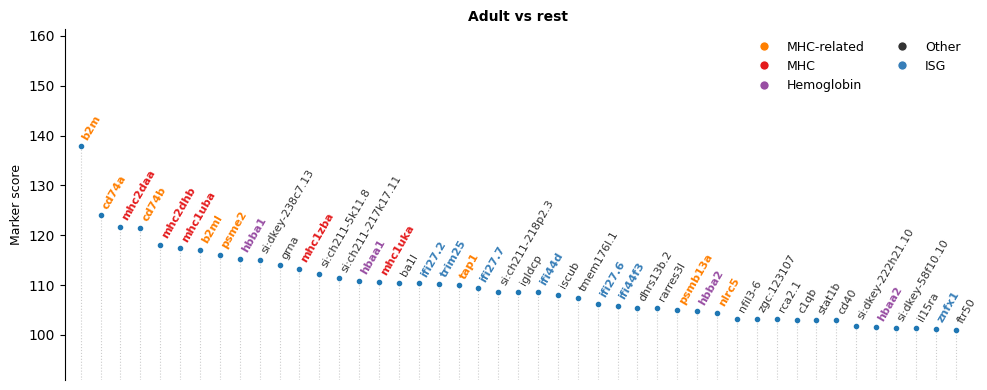

Saved to output/adult_markers_annotated_categories.pdf/.png


In [59]:
# Color palette for gene categories
CATEGORY_COLORS = {
    "MHC":              "#e41a1c",  # red
    "MHC-related":      "#ff7f00",  # orange
    "Hemoglobin":       "#984ea3",  # purple
    "ISG":              "#377eb8",  # blue
    "Complement":       "#4daf4a",  # green
    "Proinflammatory":  "#f781bf",  # pink
    "Anti-inflammatory":"#a6d854",  # lime
    "Inflammasome":     "#e7298a",  # magenta
    "Pattern Recognition":"#66c2a5",# teal
    "Adaptor/Signaling":"#8da0cb",  # light blue
    "Transcription Factor":"#fc8d62",# salmon
    "IFN":              "#1b9e77",  # dark teal
    "Chemokine":        "#d95f02",  # dark orange
    "ISG-Antiviral":    "#377eb8",  # blue (same as ISG)
    "ISG-Both":         "#377eb8",
    "ISG-Antibacterial":"#377eb8",
    "Other":            "#333333",  # dark gray
}

mpl.rcParams["pdf.fonttype"] = 42

fig, ax = plt.subplots(figsize=(10, 4))

x = np.arange(len(adult_genes))
y_min = min(adult_scores) * 0.9
score_range = max(adult_scores) - y_min
pad = score_range * 0.02

for i, (gene, score, cat) in enumerate(zip(adult_genes, adult_scores, adult_categories)):
    color = CATEGORY_COLORS.get(cat, "#333333")
    weight = "bold" if cat != "Other" else "normal"
    ax.text(
        i, score + pad, gene,
        rotation=60, ha="left", va="bottom",
        fontsize=GENE_FONTSIZE, color=color, fontweight=weight,
    )

ax.vlines(x, y_min, adult_scores, color="#cccccc", linewidth=0.8, linestyle=":")
ax.plot(x, adult_scores, "o", color="#1f77b4", markersize=3)

ax.set_title("Adult vs rest", fontsize=TITLE_FONTSIZE, fontweight="bold")
ax.set_ylabel("Marker score", fontsize=AXIS_LABEL_FONTSIZE)
ax.set_xticks([])
ax.tick_params(axis="y", labelsize=TICK_FONTSIZE)
ax.set_xlim(-0.8, len(adult_genes) - 0.2)
ax.set_ylim(y_min, max(adult_scores) + score_range * 0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)

# Legend — only show categories that appear
from matplotlib.lines import Line2D
seen_cats = list(dict.fromkeys(adult_categories))  # unique, order-preserving
legend_elements = [
    Line2D([0], [0], marker="o", color="w",
           markerfacecolor=CATEGORY_COLORS.get(cat, "#333333"),
           label=cat, markersize=7)
    for cat in seen_cats
]
ax.legend(handles=legend_elements, loc="upper right", fontsize=LEGEND_FONTSIZE - 1,
          frameon=False, ncol=2)

plt.tight_layout()
fig.savefig("output/adult_markers_annotated_categories.pdf", bbox_inches="tight")
fig.savefig("output/adult_markers_annotated_categories.png", bbox_inches="tight", dpi=300)
plt.show()
print("Saved to output/adult_markers_annotated_categories.pdf/.png")

#### Individual gene expression UMAPs for devstage markers

In [60]:
# Collect literature-validated (red/bold) genes from the devstage lollipop panels
from collections import OrderedDict

red_genes_by_stage = OrderedDict()
for stage, genes, scores in stage_panels:
    same_stage_set = lit_genes_by_stage.get(stage, set())
    matched = [g for g in genes if g in same_stage_set and g in new_adata.var_names]
    if matched:
        red_genes_by_stage[stage] = matched

# Collect top 3 non-literature markers per stage
N_TOP_NOVEL_STAGE = 3
novel_genes_by_stage = OrderedDict()
for stage, genes, scores in stage_panels:
    same_stage_set = lit_genes_by_stage.get(stage, set())
    novel = [g for g in genes if g not in all_lit_stage_genes and g in new_adata.var_names]
    novel_genes_by_stage[stage] = novel[:N_TOP_NOVEL_STAGE]

print("Devstage literature markers to plot:")
for stage, gene_list in red_genes_by_stage.items():
    print(f"  {stage}: {gene_list}")
print(f"\nTop {N_TOP_NOVEL_STAGE} novel markers per stage:")
for stage, gene_list in novel_genes_by_stage.items():
    print(f"  {stage}: {gene_list}")

Devstage literature markers to plot:
  Segmentation: ['msgn1', 'tbx6']
  Pharyngula: ['he1.1']

Top 3 novel markers per stage:
  Segmentation: ['si:dkey-195m11.8', 'greb1', 'meox1']
  Pharyngula: ['hbbe3', 'si:ch211-57n23.4', 'tnnt2c']
  Larval: ['opn1mw1', 'zgc:136930', 'opn1sw1']
  Adult: ['cd74a', 'mhc2daa', 'cd74b']


In [61]:
# Ensure new_adata has UMAP coordinates
if "X_umap" not in new_adata.obsm:
    import anndata as ad
    _umap_adata = ad.read_h5ad(CACHE_UMAP_ADATA)
    new_adata.obsm["X_umap"] = _umap_adata.obsm["X_umap"]
    del _umap_adata
    print("Loaded X_umap from cached UMAP adata")
else:
    print(f"X_umap already present: {new_adata.obsm['X_umap'].shape}")

X_umap already present: (61615, 2)


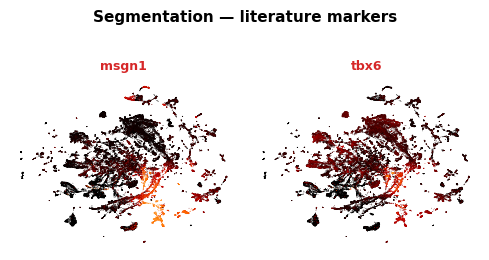

Saved 2 UMAPs for Segmentation -> output/umap_expression_Segmentation_lit_markers.pdf, output/umap_expression_Segmentation_lit_markers.png


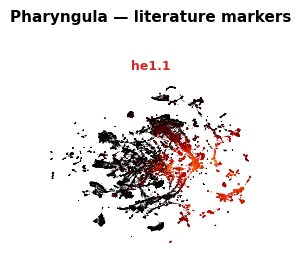

Saved 1 UMAPs for Pharyngula -> output/umap_expression_Pharyngula_lit_markers.pdf, output/umap_expression_Pharyngula_lit_markers.png


In [62]:
# UMAP plot settings (shared with tissue UMAP cells below)
UMAP_SIZE = 2.5        # inches per panel
UMAP_POINT_SIZE = 1
UMAP_FONTSIZE = 9
UMAP_CMAP = "gist_heat"
UMAP_DPI = 300

# Plot UMAPs for devstage literature-validated markers
mpl.rcParams["pdf.fonttype"] = 42

for stage, gene_list in red_genes_by_stage.items():
    if not gene_list:
        continue

    ncols = min(len(gene_list), 4)
    nrows = (len(gene_list) + ncols - 1) // ncols

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(UMAP_SIZE * ncols, UMAP_SIZE * nrows),
        squeeze=False,
    )

    for idx, gene in enumerate(gene_list):
        ax = axes[idx // ncols][idx % ncols]
        sc.pl.umap(
            new_adata,
            color=gene,
            layer="log2tmmcpm",
            cmap=UMAP_CMAP,
            size=UMAP_POINT_SIZE,
            frameon=False,
            title=gene,
            show=False,
            ax=ax,
            colorbar_loc=None,
        )
        ax.set_title(gene, fontsize=UMAP_FONTSIZE, fontweight="bold", color=HIGHLIGHT_COLOR)
        ax.set_xlabel("")
        ax.set_ylabel("")

    for idx in range(len(gene_list), nrows * ncols):
        axes[idx // ncols][idx % ncols].set_visible(False)

    fig.suptitle(f"{stage} — literature markers", fontsize=UMAP_FONTSIZE + 2, fontweight="bold", y=1.02)
    plt.tight_layout()

    safe_name = stage.replace(" ", "_").replace("/", "-")
    pdf_path = f"output/umap_expression_{safe_name}_lit_markers.pdf"
    png_path = f"output/umap_expression_{safe_name}_lit_markers.png"
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, bbox_inches="tight", dpi=UMAP_DPI)
    plt.show()
    print(f"Saved {len(gene_list)} UMAPs for {stage} -> {pdf_path}, {png_path}")

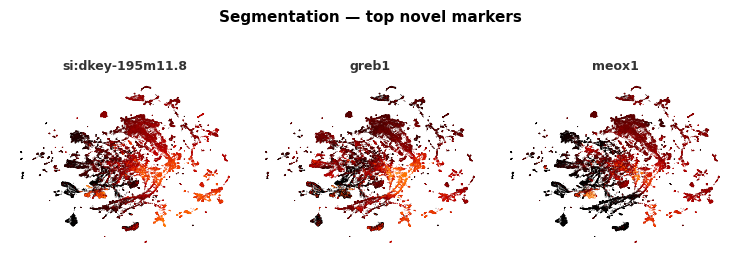

Saved 3 UMAPs for Segmentation -> output/umap_expression_Segmentation_novel_markers.pdf, output/umap_expression_Segmentation_novel_markers.png


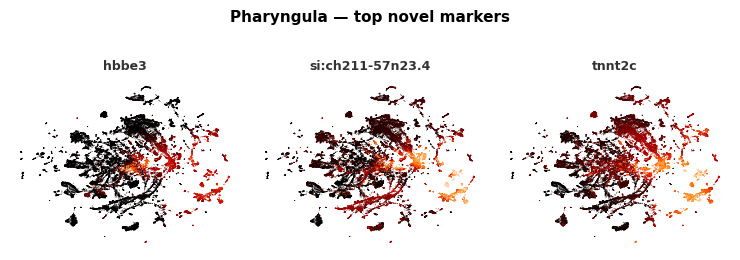

Saved 3 UMAPs for Pharyngula -> output/umap_expression_Pharyngula_novel_markers.pdf, output/umap_expression_Pharyngula_novel_markers.png


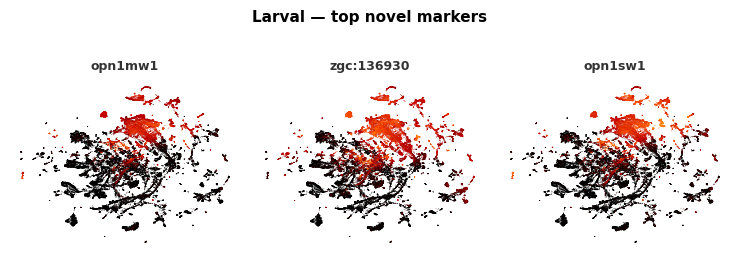

Saved 3 UMAPs for Larval -> output/umap_expression_Larval_novel_markers.pdf, output/umap_expression_Larval_novel_markers.png


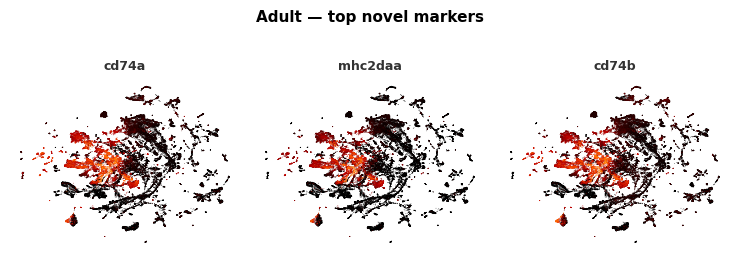

Saved 3 UMAPs for Adult -> output/umap_expression_Adult_novel_markers.pdf, output/umap_expression_Adult_novel_markers.png


In [63]:
# Plot UMAPs for devstage top novel markers
for stage, gene_list in novel_genes_by_stage.items():
    if not gene_list:
        continue

    ncols = min(len(gene_list), 4)
    nrows = (len(gene_list) + ncols - 1) // ncols

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(UMAP_SIZE * ncols, UMAP_SIZE * nrows),
        squeeze=False,
    )

    for idx, gene in enumerate(gene_list):
        ax = axes[idx // ncols][idx % ncols]
        sc.pl.umap(
            new_adata,
            color=gene,
            layer="log2tmmcpm",
            cmap=UMAP_CMAP,
            size=UMAP_POINT_SIZE,
            frameon=False,
            title=gene,
            show=False,
            ax=ax,
            colorbar_loc=None,
        )
        ax.set_title(gene, fontsize=UMAP_FONTSIZE, fontweight="bold", color=DEFAULT_COLOR)
        ax.set_xlabel("")
        ax.set_ylabel("")

    for idx in range(len(gene_list), nrows * ncols):
        axes[idx // ncols][idx % ncols].set_visible(False)

    fig.suptitle(f"{stage} — top novel markers", fontsize=UMAP_FONTSIZE + 2, fontweight="bold", y=1.02)
    plt.tight_layout()
 
    safe_name = stage.replace(" ", "_").replace("/", "-")
    pdf_path = f"output/umap_expression_{safe_name}_novel_markers.pdf"
    png_path = f"output/umap_expression_{safe_name}_novel_markers.png"
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, bbox_inches="tight", dpi=UMAP_DPI)
    plt.show()
    print(f"Saved {len(gene_list)} UMAPs for {stage} -> {pdf_path}, {png_path}")

#### Individual gene expression UMAPs for literature-validated markers

Small UMAPs colored by expression of each red/bold gene from the lollipop panels.
Intended for use as insets overlaid on the lollipop plots.

In [64]:
# Collect red/bold genes (same-tissue literature matches) from the lollipop panels
red_genes_by_tissue = {}
for tissue, genes, scores in panels:
    same_tissue_set = lit_genes_by_tissue.get(tissue, set())
    matched = [(g, s) for g, s in zip(genes, scores) if g in same_tissue_set]
    if matched:
        red_genes_by_tissue[tissue] = matched

# Flatten to a unique list preserving tissue grouping
all_red_genes = []
for tissue, gene_score_pairs in red_genes_by_tissue.items():
    for gene, score in gene_score_pairs:
        all_red_genes.append((tissue, gene))

print(f"Red/bold genes to plot ({len(all_red_genes)} total):")
for tissue, gene in all_red_genes:
    in_var = gene in new_adata.var_names
    print(f"  {tissue:30s} | {gene:15s} | in var_names: {in_var}")

Red/bold genes to plot (10 total):
  Reproductive System            | piwil1          | in var_names: True
  Reproductive System            | ddx4            | in var_names: True
  Reproductive System            | piwil2          | in var_names: True
  Reproductive System            | dnd1            | in var_names: True
  Skeletal Element               | runx2b          | in var_names: True
  Digestive System               | cldn15la        | in var_names: True
  Digestive System               | vil1            | in var_names: True
  Endocrine System               | pdx1            | in var_names: True
  Endocrine System               | ins             | in var_names: True
  Endocrine System               | gcga            | in var_names: True


In [65]:
# Ensure new_adata has UMAP coordinates
if "X_umap" not in new_adata.obsm:
    # Load from cached UMAP adata
    import anndata as ad
    _umap_adata = ad.read_h5ad(CACHE_UMAP_ADATA)
    new_adata.obsm["X_umap"] = _umap_adata.obsm["X_umap"]
    del _umap_adata
    print("Loaded X_umap from cached UMAP adata")
else:
    print(f"X_umap already present: {new_adata.obsm['X_umap'].shape}")

X_umap already present: (61615, 2)


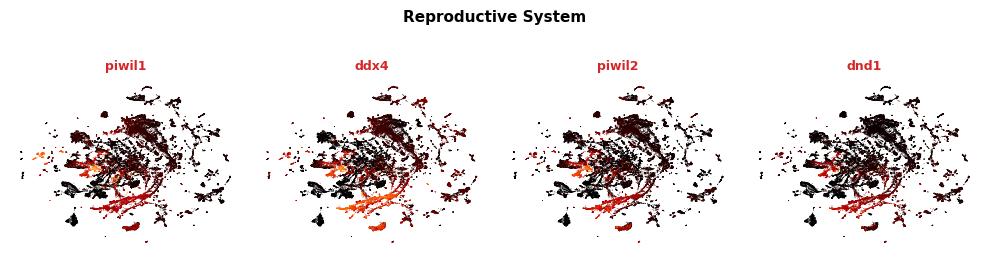

Saved 4 UMAPs for Reproductive System -> output/umap_expression_Reproductive_System_lit_markers.pdf, output/umap_expression_Reproductive_System_lit_markers.png


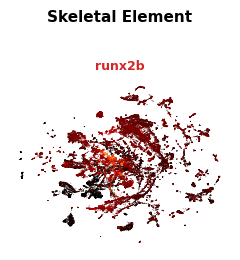

Saved 1 UMAPs for Skeletal Element -> output/umap_expression_Skeletal_Element_lit_markers.pdf, output/umap_expression_Skeletal_Element_lit_markers.png


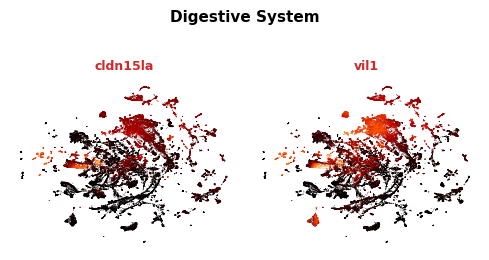

Saved 2 UMAPs for Digestive System -> output/umap_expression_Digestive_System_lit_markers.pdf, output/umap_expression_Digestive_System_lit_markers.png


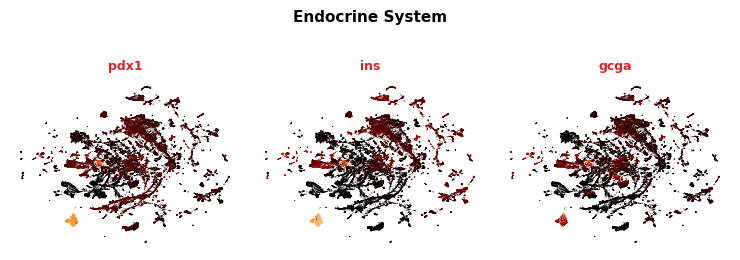

Saved 3 UMAPs for Endocrine System -> output/umap_expression_Endocrine_System_lit_markers.pdf, output/umap_expression_Endocrine_System_lit_markers.png


In [66]:
# Plot individual gene expression UMAPs — one per red/bold gene
# Small square panels suitable for insets

UMAP_SIZE = 2.5        # inches per panel
UMAP_POINT_SIZE = 1
UMAP_FONTSIZE = 9
UMAP_CMAP = "gist_heat"
UMAP_DPI = 300

mpl.rcParams["pdf.fonttype"] = 42

# Filter to genes actually in var_names
plot_genes = [(tissue, gene) for tissue, gene in all_red_genes if gene in new_adata.var_names]

if not plot_genes:
    print("No red/bold genes found in new_adata.var_names — skipping UMAP plots")
else:
    # Group by tissue for organized output
    from collections import OrderedDict
    genes_by_tissue = OrderedDict()
    for tissue, gene in plot_genes:
        genes_by_tissue.setdefault(tissue, []).append(gene)

    for tissue, gene_list in genes_by_tissue.items():
        ncols = min(len(gene_list), 4)
        nrows = (len(gene_list) + ncols - 1) // ncols

        fig, axes = plt.subplots(
            nrows, ncols,
            figsize=(UMAP_SIZE * ncols, UMAP_SIZE * nrows),
            squeeze=False,
        )

        for idx, gene in enumerate(gene_list):
            ax = axes[idx // ncols][idx % ncols]
            sc.pl.umap(
                new_adata,
                color=gene,
                layer="log2tmmcpm",
                cmap=UMAP_CMAP,
                size=UMAP_POINT_SIZE,
                frameon=False,
                title=gene,
                show=False,
                ax=ax,
                colorbar_loc=None,
            )
            ax.set_title(gene, fontsize=UMAP_FONTSIZE, fontweight="bold", color=HIGHLIGHT_COLOR)
            ax.set_xlabel("")
            ax.set_ylabel("")

        # Hide unused axes
        for idx in range(len(gene_list), nrows * ncols):
            axes[idx // ncols][idx % ncols].set_visible(False)

        fig.suptitle(tissue, fontsize=UMAP_FONTSIZE + 2, fontweight="bold", y=1.02)
        plt.tight_layout()

        safe_name = tissue.replace(" ", "_").replace("/", "-")
        pdf_path = f"output/umap_expression_{safe_name}_lit_markers.pdf"
        png_path = f"output/umap_expression_{safe_name}_lit_markers.png"
        fig.savefig(pdf_path, bbox_inches="tight")
        fig.savefig(png_path, bbox_inches="tight", dpi=UMAP_DPI)
        plt.show()
        print(f"Saved {len(gene_list)} UMAPs for {tissue} -> {pdf_path}, {png_path}")

In [67]:
# Collect top 3 non-literature markers per tissue
N_TOP_NOVEL = 3

novel_genes_by_tissue = OrderedDict()
for tissue, genes, scores in panels:
    same_tissue_set = lit_genes_by_tissue.get(tissue, set())
    novel = [(g, s) for g, s in zip(genes, scores) if g not in all_lit_genes and g in new_adata.var_names]
    novel_genes_by_tissue[tissue] = [g for g, s in novel[:N_TOP_NOVEL]]

print(f"Top {N_TOP_NOVEL} novel (non-literature) markers per tissue:")
for tissue, gene_list in novel_genes_by_tissue.items():
    print(f"  {tissue}: {gene_list}")

Top 3 novel (non-literature) markers per tissue:
  Reproductive System: ['tdrd1', 'tdrd7a', 'rbm44']
  Skeletal Element: ['tnfrsf11a', 'spp1', 'ltbp3']
  Digestive System: ['si:ch211-202h22.9', 'si:dkey-250k15.7', 'anpeplb']
  Endocrine System: ['scg3', 'scg5', 'scgn']


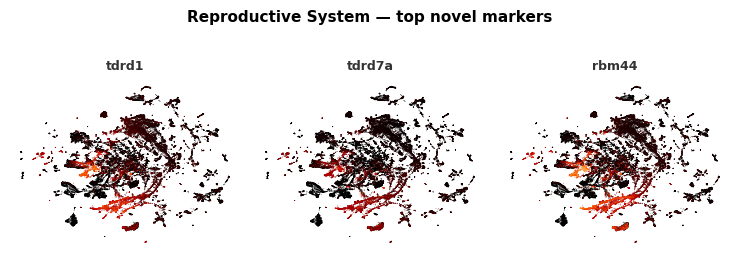

Saved 3 UMAPs for Reproductive System -> output/umap_expression_Reproductive_System_novel_markers.pdf, output/umap_expression_Reproductive_System_novel_markers.png


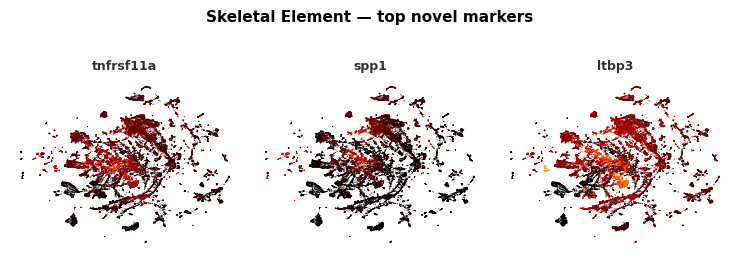

Saved 3 UMAPs for Skeletal Element -> output/umap_expression_Skeletal_Element_novel_markers.pdf, output/umap_expression_Skeletal_Element_novel_markers.png


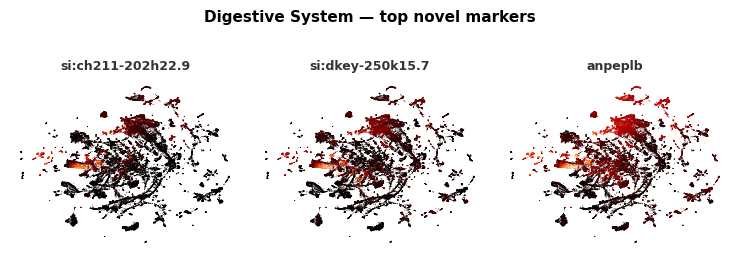

Saved 3 UMAPs for Digestive System -> output/umap_expression_Digestive_System_novel_markers.pdf, output/umap_expression_Digestive_System_novel_markers.png


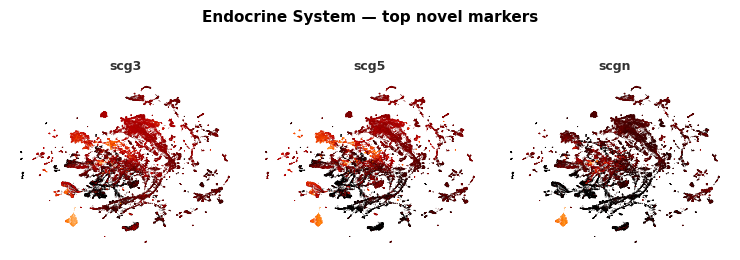

Saved 3 UMAPs for Endocrine System -> output/umap_expression_Endocrine_System_novel_markers.pdf, output/umap_expression_Endocrine_System_novel_markers.png


In [68]:
# Plot UMAPs for top novel markers — same style as literature marker UMAPs
for tissue, gene_list in novel_genes_by_tissue.items():
    if not gene_list:
        continue

    ncols = min(len(gene_list), 4)
    nrows = (len(gene_list) + ncols - 1) // ncols

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(UMAP_SIZE * ncols, UMAP_SIZE * nrows),
        squeeze=False,
    )

    for idx, gene in enumerate(gene_list):
        ax = axes[idx // ncols][idx % ncols]
        sc.pl.umap(
            new_adata,
            color=gene,
            layer="log2tmmcpm",
            cmap=UMAP_CMAP,
            size=UMAP_POINT_SIZE,
            frameon=False,
            title=gene,
            show=False,
            ax=ax,
            colorbar_loc=None,
        )
        ax.set_title(gene, fontsize=UMAP_FONTSIZE, fontweight="bold", color=DEFAULT_COLOR)
        ax.set_xlabel("")
        ax.set_ylabel("")

    for idx in range(len(gene_list), nrows * ncols):
        axes[idx // ncols][idx % ncols].set_visible(False)

    fig.suptitle(f"{tissue} — top novel markers", fontsize=UMAP_FONTSIZE + 2, fontweight="bold", y=1.02)
    plt.tight_layout()

    safe_name = tissue.replace(" ", "_").replace("/", "-")
    pdf_path = f"output/umap_expression_{safe_name}_novel_markers.pdf"
    png_path = f"output/umap_expression_{safe_name}_novel_markers.png"
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, bbox_inches="tight", dpi=UMAP_DPI)
    plt.show()
    print(f"Saved {len(gene_list)} UMAPs for {tissue} -> {pdf_path}, {png_path}")